## MTH9899 - Final Project, Chaithanya Pakala and Tian Tian

## Imports

In [72]:
pip install xgboost


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [73]:
import sys
from pathlib import Path

# Add project root to path so `src` package is importable
_project_root = Path.cwd().parent  # submission_files -> MTH9899_ProjectFinal
if str(_project_root) not in sys.path:
    sys.path.insert(0, str(_project_root))

import pandas as pd
from src.config import FEATURE_DATA_DIR, RAW_DATA_DIR, ROOT_DIR

## Feature Visualization

In [74]:
feat_train_path = FEATURE_DATA_DIR / "feature_together" / "features_train.parquet"
df_feat_train = pd.read_parquet(feat_train_path)

In [75]:
df_feat_train.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 502499 entries, 2010-01-04 to 2013-12-31
Data columns (total 20 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   Id                                   502499 non-null  str    
 1   intraday_momentum                    501828 non-null  float64
 2   intraday_reversal                    501828 non-null  float64
 3   resid_vol                            501828 non-null  float64
 4   intraday_skewness                    501828 non-null  float64
 5   early_late_volume_mix                501828 non-null  float64
 6   return_volume_corr                   501827 non-null  float64
 7   lag1_autocorr                        501828 non-null  float64
 8   closing_auction_participation_ratio  496637 non-null  float64
 9   intraday_kurtosis                    501828 non-null  float64
 10  intraday_vwap_deviation              501827 non-null  float64
 11  intraday

In [76]:
# Lets handle the nulls carefully 
df_feat_train['open_to_close_return'].isnull().sum()

np.int64(1742)

### NaN Diagnosis — Understanding Where NaNs Come From

In [77]:
import numpy as np

feature_cols = [c for c in df_feat_train.columns if c not in ["Id", "target_variable"]]
target_col = "target_variable"

# ── 1. Overall NaN summary per column ──────────────────────────────────
total = len(df_feat_train)
nan_summary = pd.DataFrame({
    "non_null": df_feat_train[feature_cols + [target_col]].count(),
    "null":     df_feat_train[feature_cols + [target_col]].isnull().sum(),
}).assign(null_pct=lambda d: (d["null"] / total * 100).round(2))
nan_summary = nan_summary.sort_values("null", ascending=False)
print(f"Total rows: {total:,}\n")
nan_summary

Total rows: 502,499



,non_null,null,null_pct
mean_reversion_ma,456184,46315,9.22
target_variable,490284,12215,2.43
late_day_trend,495169,7330,1.46
closing_auction_participation_ratio,496637,5862,1.17
bollinger_band,497848,4651,0.93
raw_momentum,498422,4077,0.81
short_term_reversal,499973,2526,0.50
intraday_volume_concentration,500609,1890,0.38
close_position_daily_range,500757,1742,0.35
open_to_close_return,500757,1742,0.35


In [78]:
# ── 2. Classify features by NaN mechanism ──────────────────────────────
#
# Group A  — "Core intraday" (~671 NaNs each, 0.13%)
#   intraday_momentum, intraday_reversal, resid_vol, intraday_skewness,
#   early_late_volume_mix, lag1_autocorr, intraday_kurtosis
#   → NaN when a stock-day was dropped entirely during intraday cleaning
#     (the stock had a NaN in at least one 15-min bar that day).
#     These are "universe NaNs" — the stock simply wasn't available.
#
# Group B  — "Intraday edge cases" (672–5,862 NaNs)
#   return_volume_corr, intraday_vwap_deviation (~672)
#     → same as Group A + div-by-zero when volume or std is exactly 0
#   intraday_volume_concentration (~1,890)
#     → total volume = 0 in the time window
#   closing_auction_participation_ratio (~5,862)
#     → CumVol@15:30 = 0  (no 15:30 volume snapshot)
#
# Group C  — "Rolling lookback warmup" (1,742–46,315 NaNs)
#   open_to_close_return, close_position_daily_range (~1,742)
#     → stock's first appearance in daily data (no T-1 bar)
#   short_term_reversal (~2,526)  — 1-day lag
#   raw_momentum (~4,077)         — 5-day cumret with shift(2)
#   bollinger_band (~4,651)       — SMA(5) + rolling_std(5)
#   late_day_trend (~7,330)       — 10-day rolling mean of late_mom
#   mean_reversion_ma (~46,315)   — SMA(120) needs ~120 days of history!
#
# Group D  — "Target"  (~12,215 NaNs)
#   target_variable
#     → missing when next trading day data doesn't exist
#       (last day of dataset, or stock drops out of universe next day)

# Verify: do the ~671 "Group A" NaN rows share the same (Date, Id)?
intraday_core = ["intraday_momentum", "resid_vol", "intraday_skewness",
                 "intraday_reversal", "early_late_volume_mix", "lag1_autocorr",
                 "intraday_kurtosis"]
mask_core_nan = df_feat_train[intraday_core].isnull().any(axis=1)
mask_core_all_nan = df_feat_train[intraday_core].isnull().all(axis=1)
print(f"Rows where ANY core intraday feature is NaN:  {mask_core_nan.sum()}")
print(f"Rows where ALL core intraday features are NaN: {mask_core_all_nan.sum()}")
print("→ They are identical: these stocks have no intraday data for that day.\n")

# Check if those same rows are NaN across ALL features
all_feat_nan = df_feat_train[feature_cols].isnull().all(axis=1)
print(f"Rows where ALL features are NaN: {all_feat_nan.sum()}")
print(f"Rows where core is NaN but some feature exists: {(mask_core_nan & ~all_feat_nan).sum()}")

Rows where ANY core intraday feature is NaN:  671
Rows where ALL core intraday features are NaN: 671
→ They are identical: these stocks have no intraday data for that day.

Rows where ALL features are NaN: 576
Rows where core is NaN but some feature exists: 95


In [79]:
# ── 3. Prove that mean_reversion_ma NaNs are a rolling-warmup effect ───
# If NaNs come from insufficient history, they should concentrate in the
# first ~120 trading days for each stock.

df = df_feat_train.reset_index().rename(columns={"index": "Date"}) if df_feat_train.index.name is None else df_feat_train.reset_index()

# For each Id, count how many trading days of history exist before each row
df["_day_rank"] = df.groupby("Id")["Date"].rank(method="first").astype(int)

# Where is mean_reversion_ma NaN?
mr_nan = df[df["mean_reversion_ma"].isnull()]
print(f"mean_reversion_ma NaN rows: {len(mr_nan):,}")
print(f"  max _day_rank among NaN rows: {mr_nan['_day_rank'].max()}")
print(f"  median _day_rank:             {mr_nan['_day_rank'].median():.0f}")
print(f"  rows with _day_rank <= 120:   {(mr_nan['_day_rank'] <= 120).sum():,}")
print(f"  rows with _day_rank >  120:   {(mr_nan['_day_rank'] > 120).sum():,}")
print()

# Same check for bollinger_band (K=5) and raw_momentum (K=5, shift=2)
for col, expected_warmup in [("bollinger_band", 5), ("raw_momentum", 7),
                              ("short_term_reversal", 2), ("late_day_trend", 11)]:
    col_nan = df[df[col].isnull()]
    within = (col_nan["_day_rank"] <= expected_warmup).sum()
    beyond = (col_nan["_day_rank"] > expected_warmup).sum()
    print(f"{col} ({len(col_nan):,} NaNs): "
          f"{within:,} within first {expected_warmup} days, "
          f"{beyond:,} beyond  →  "
          f"{'pure warmup ✓' if beyond < 0.02 * len(col_nan) else 'mixed: warmup + missing daily data'}")

mean_reversion_ma NaN rows: 46,315
  max _day_rank among NaN rows: 105
  median _day_rank:             30
  rows with _day_rank <= 120:   46,315
  rows with _day_rank >  120:   0

bollinger_band (4,651 NaNs): 2,039 within first 5 days, 2,612 beyond  →  mixed: warmup + missing daily data
raw_momentum (4,077 NaNs): 3,647 within first 7 days, 430 beyond  →  mixed: warmup + missing daily data
short_term_reversal (2,526 NaNs): 1,626 within first 2 days, 900 beyond  →  mixed: warmup + missing daily data
late_day_trend (7,330 NaNs): 1,357 within first 11 days, 5,973 beyond  →  mixed: warmup + missing daily data


In [80]:
# ── 4. Investigate "beyond warmup" NaNs in daily features ──────────────
# These come from stocks that exist in the intraday universe but are
# missing from the daily panel on T-1 (so the daily→intraday join fails).

# Check: among bollinger_band NaN rows with _day_rank > 5, how many also
# have NaN in ALL daily features?
daily_feat_cols = ["mean_reversion_ma", "short_term_reversal", "bollinger_band",
                   "raw_momentum", "open_to_close_return", "close_position_daily_range"]

beyond_warmup = df[(df["bollinger_band"].isnull()) & (df["_day_rank"] > 5)]
daily_all_nan = beyond_warmup[daily_feat_cols].isnull().all(axis=1)
daily_any_non_nan = ~daily_all_nan

print(f"bollinger_band NaN rows beyond warmup: {len(beyond_warmup):,}")
print(f"  ALL daily features NaN (stock missing from daily panel): {daily_all_nan.sum():,}")
print(f"  Some daily features present (partial NaN):              {daily_any_non_nan.sum():,}")
print()

# Confirm: the "missing daily" rows also have NaN for open_to_close_return
# and close_position_daily_range (which need only 1 day of daily data)
missing_daily_mask = df[daily_feat_cols].isnull().all(axis=1) & (df["_day_rank"] > 1)
print(f"Rows where ALL daily features are NaN (beyond first day): {missing_daily_mask.sum():,}")
print("→ These are (Date, Id) pairs where the stock has intraday data")
print("  but NO daily OHLCV on T-1. The daily→intraday join produced NaN.\n")

# How are these distributed over time?
missing_daily_dates = df.loc[missing_daily_mask, "Date"].value_counts().sort_index()
print(f"Affected dates: {len(missing_daily_dates):,} out of {df['Date'].nunique():,} trading days")
print(f"Affected (Date, Id) pairs: {missing_daily_mask.sum():,}")
print(f"Mean per affected date: {missing_daily_dates.mean():.1f} stocks/day")

bollinger_band NaN rows beyond warmup: 2,612
  ALL daily features NaN (stock missing from daily panel): 493
  Some daily features present (partial NaN):              2,119

Rows where ALL daily features are NaN (beyond first day): 929
→ These are (Date, Id) pairs where the stock has intraday data
  but NO daily OHLCV on T-1. The daily→intraday join produced NaN.

Affected dates: 565 out of 1,006 trading days
Affected (Date, Id) pairs: 929
Mean per affected date: 1.6 stocks/day


In [81]:
# ── 5. Target NaN diagnosis ─────────────────────────────────────────────
# target = ResidReturn(T, 16:00) + CumReturnResid(T+1_next_trading_day, 15:30)
# NaN when: (a) no next trading day data, or (b) stock drops out of universe.

target_nan = df[df["target_variable"].isnull()]
target_ok  = df[df["target_variable"].notna()]

# Is it the last trading day per stock?
last_day = df.groupby("Id")["Date"].transform("max")
is_last_day = df["Date"] == last_day

print(f"Target NaN rows: {len(target_nan):,}")
print(f"  On stock's last available day:          {(target_nan['Date'] == last_day[target_nan.index]).sum():,}")
print(f"  On other days (stock drops out briefly): {(target_nan['Date'] != last_day[target_nan.index]).sum():,}")
print()

# Does the NaN cluster at the end of the training set?
last_train_date = df["Date"].max()
print(f"Last training date: {last_train_date.date()}")
print(f"Target NaN on {last_train_date.date()}: {(target_nan['Date'] == last_train_date).sum():,}")
print(f"Target NaN on other dates:          {(target_nan['Date'] != last_train_date).sum():,}")

Target NaN rows: 12,215
  On stock's last available day:          822
  On other days (stock drops out briefly): 11,393

Last training date: 2013-12-31
Target NaN on 2013-12-31: 500
Target NaN on other dates:          11,715


In [82]:
# ── 6. late_day_trend "beyond warmup" NaNs ─────────────────────────────
# late_day_trend = late_mom(today) - rolling_mean(late_mom, K=10, shift=1)
# The rolling mean uses .shift(1).rolling(10, min_periods=1).mean()
# So NaN only on the very first day per stock (no shifted history).
# But we see 5,973 NaNs beyond day 11 — why?
#
# Likely cause: late_day_trend is computed from ResidReturn 15:00-15:30,
# and its rolling mean is per-Id in the unstack→stack path.
# If a stock is missing for a stretch (no intraday data), the unstacked
# column has NaN for those dates, causing the rolling mean to be NaN.

ldt_nan_beyond = df[(df["late_day_trend"].isnull()) & (df["_day_rank"] > 11)]
# Check: do these stocks have gaps in their trading calendar?
gap_check = []
for _, row in ldt_nan_beyond.head(20).iterrows():
    stock_dates = df.loc[df["Id"] == row["Id"], "Date"].sort_values()
    idx = stock_dates[stock_dates <= row["Date"]].index
    if len(idx) >= 2:
        prev_date = stock_dates.loc[idx[-2]] if len(idx) >= 2 else None
        gap_days = (row["Date"] - prev_date).days if prev_date is not None else None
        gap_check.append({"Id": row["Id"], "Date": row["Date"].date(),
                          "prev_date": prev_date.date() if prev_date else None,
                          "gap_days": gap_days})

gap_df = pd.DataFrame(gap_check)
print("late_day_trend: sample NaN rows beyond warmup (checking for date gaps):")
print(gap_df.to_string(index=False))
print(f"\nMedian gap between appearances: {gap_df['gap_days'].median():.0f} calendar days")

late_day_trend: sample NaN rows beyond warmup (checking for date gaps):
          Id       Date  prev_date  gap_days
BBG000D2M0Z7 2010-01-26 2010-01-25         1
BBG000D6L294 2010-01-28 2010-01-27         1
BBG000BL5W86 2010-01-29 2010-01-26         3
BBG000BBMT95 2010-02-01 2010-01-27         5
BBG000CPHYL4 2010-02-08 2010-02-05         3
BBG000D2M0Z7 2010-02-08 2010-02-01         7
BBG000HS74G6 2010-02-08 2010-02-05         3
BBG000MQ1SN9 2010-02-09 2010-02-08         1
BBG000BL5W86 2010-02-10 2010-02-03         7
BBG000D6L294 2010-02-12 2010-01-29        14
BBG000J0D904 2010-02-12 2010-02-11         1
BBG000BN1XR3 2010-02-16 2010-02-09         7
BBG000D6L294 2010-02-16 2010-02-12         4
BBG000D2M0Z7 2010-02-17 2010-02-12         5
BBG000J0D904 2010-02-17 2010-02-16         1
BBG000D2M0Z7 2010-02-22 2010-02-19         3
BBG000J0D904 2010-02-22 2010-02-18         4
BBG000BC9938 2010-02-24 2010-02-12        12
BBG000BL5W86 2010-02-24 2010-02-23         1
BBG000BR32C6 2010-03-01 2010

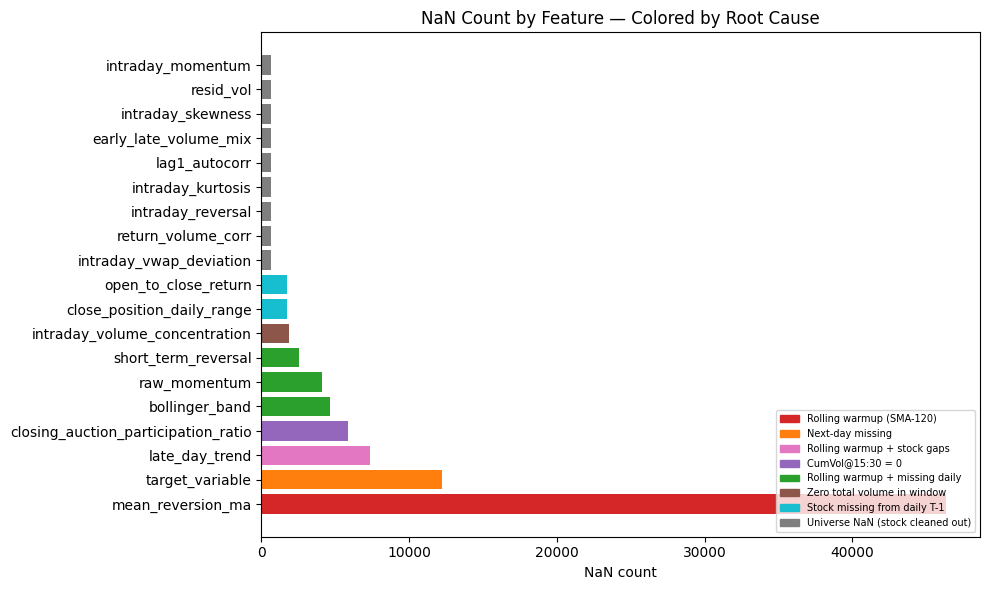

In [83]:
# ── 7. Final NaN origin summary & visual ───────────────────────────────
import matplotlib.pyplot as plt

nan_causes = pd.DataFrame({
    "feature": nan_summary.index,
    "null_count": nan_summary["null"].values,
    "mechanism": [
        "Rolling warmup (SMA-120)",             # mean_reversion_ma
        "Next-day missing",                      # target_variable
        "Rolling warmup + stock gaps",           # late_day_trend
        "CumVol@15:30 = 0",                     # closing_auction_participation_ratio
        "Rolling warmup + missing daily",        # bollinger_band
        "Rolling warmup + missing daily",        # raw_momentum
        "Rolling warmup + missing daily",        # short_term_reversal
        "Zero total volume in window",           # intraday_volume_concentration
        "Stock missing from daily T-1",          # close_position_daily_range
        "Stock missing from daily T-1",          # open_to_close_return
        "Universe NaN (stock cleaned out)",      # intraday_vwap_deviation
        "Universe NaN (stock cleaned out)",      # return_volume_corr
        "Universe NaN (stock cleaned out)",      # intraday_reversal
        "Universe NaN (stock cleaned out)",      # intraday_kurtosis
        "Universe NaN (stock cleaned out)",      # lag1_autocorr
        "Universe NaN (stock cleaned out)",      # early_late_volume_mix
        "Universe NaN (stock cleaned out)",      # intraday_skewness
        "Universe NaN (stock cleaned out)",      # resid_vol
        "Universe NaN (stock cleaned out)",      # intraday_momentum
    ]
}).set_index("feature")

fig, ax = plt.subplots(figsize=(10, 6))
colors = nan_causes["mechanism"].map({
    "Rolling warmup (SMA-120)":         "#d62728",
    "Next-day missing":                  "#ff7f0e",
    "Rolling warmup + stock gaps":       "#e377c2",
    "CumVol@15:30 = 0":                 "#9467bd",
    "Rolling warmup + missing daily":    "#2ca02c",
    "Zero total volume in window":       "#8c564b",
    "Stock missing from daily T-1":      "#17becf",
    "Universe NaN (stock cleaned out)":  "#7f7f7f",
})
ax.barh(nan_causes.index, nan_causes["null_count"], color=colors)
ax.set_xlabel("NaN count")
ax.set_title("NaN Count by Feature — Colored by Root Cause")

# Legend
from matplotlib.patches import Patch
handles = [Patch(color=c, label=l) for l, c in {
    "Rolling warmup (SMA-120)":         "#d62728",
    "Next-day missing":                  "#ff7f0e",
    "Rolling warmup + stock gaps":       "#e377c2",
    "CumVol@15:30 = 0":                 "#9467bd",
    "Rolling warmup + missing daily":    "#2ca02c",
    "Zero total volume in window":       "#8c564b",
    "Stock missing from daily T-1":      "#17becf",
    "Universe NaN (stock cleaned out)":  "#7f7f7f",
}.items()]
ax.legend(handles=handles, fontsize=7, loc="lower right")
plt.tight_layout()
plt.show()

## Model 1: Ridge Regression

### Model Selection Design: Simple Train/Valid Split

- **Train/Valid split:** 2010–2013 split into train/valid (80/20 by date)
- **Grid search:**
    - Ridge Regression:
        ```python
        ridge_param_grid = {
            "alpha": [0.01, 0.1, 1, 10, 100]
        }
        ```
- **Best HPs** found on validation set, then final evaluation on 2014 OOS.

**No walk-forward or purged CV.**

In [84]:
# ── 8. Apply NaN handling via reusable function ────────────────────────
from feature_src.nan_handler import clean_feature_panel

df_train_clean = clean_feature_panel(df_feat_train, verbose=True)

[1] Drop target NaN:          502,499 → 490,284  (−12,215)
[2] Drop all-NaN rows:        490,284 → 490,284  (−0)
[3] Fill closing_auction_participation_ratio: 4 NaNs → 0
[3] Fill intraday_volume_concentration: 4 NaNs → 0
[4] Median-fill mean_reversion_ma: 44,648 → 29,489 NaNs
[4] Median-fill bollinger_band: 2,737 → 981 NaNs
[4] Median-fill raw_momentum: 3,267 → 1,961 NaNs
[4] Median-fill short_term_reversal: 1,787 → 981 NaNs
[4] Median-fill late_day_trend: 1,330 → 491 NaNs
[4] Median-fill open_to_close_return: 1,051 → 491 NaNs
[4] Median-fill close_position_daily_range: 1,051 → 491 NaNs
[5] Warmup cutoff (auto):     2010-06-25
    Rows after cutoff:        490,284 → 431,257  (−59,027)
[6] No remaining NaNs ✓

 Clean: 431,257 rows × 18 features, 0 NaNs


In [85]:
# ── 9. Apply the same pipeline to the test set ─────────────────────────
feat_test_path = FEATURE_DATA_DIR / "feature_together" / "features_test.parquet"
df_feat_test = pd.read_parquet(feat_test_path)
print(f"Test set raw: {len(df_feat_test):,} rows, "
      f"{df_feat_test.index.min().date()} → {df_feat_test.index.max().date()}\n")

# Pass the training cutoff so train and test share the same warmup logic.
# Test set (2014) is well past warmup, so no rows are dropped by date.
train_cutoff = df_train_clean.index.min()
df_test_clean = clean_feature_panel(
    df_feat_test,
    warmup_cutoff=train_cutoff,
    verbose=True,
)

Test set raw: 126,245 rows, 2014-01-02 → 2014-12-31

[1] Drop target NaN:          126,245 → 121,866  (−4,379)
[2] Drop all-NaN rows:        121,866 → 121,866  (−0)
[4] Median-fill mean_reversion_ma: 3,007 → 0 NaNs
[4] Median-fill bollinger_band: 409 → 0 NaNs
[4] Median-fill raw_momentum: 222 → 0 NaNs
[4] Median-fill short_term_reversal: 124 → 0 NaNs
[4] Median-fill late_day_trend: 207 → 0 NaNs
[4] Median-fill open_to_close_return: 81 → 0 NaNs
[4] Median-fill close_position_daily_range: 81 → 0 NaNs
[5] Warmup cutoff (provided): 2010-06-25
    Rows after cutoff:        121,866 → 121,866  (−0)
[6] No remaining NaNs ✓

 Clean: 121,866 rows × 18 features, 0 NaNs


## Dataset & Feature Description

In [86]:
# ── 1. Dataset overview ─────────────────────────────────────────────────
print("=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)
print(f"Shape:          {df_train_clean.shape[0]:,} rows × {df_train_clean.shape[1]} columns")
print(f"Date range:     {df_train_clean.index.min().date()} → {df_train_clean.index.max().date()}")
print(f"Unique dates:   {df_train_clean.index.nunique()}")
print(f"Unique stocks:  {df_train_clean['Id'].nunique()}")
print(f"Stocks/day:     {df_train_clean.groupby(df_train_clean.index)['Id'].nunique().describe()[['mean','min','max']].to_dict()}")
print(f"\nTarget:         target_variable = ResidReturn(T,16:00) + CumReturnResid(T+1,15:30)")
print(f"                i.e. the residual return from 15:30 today to 15:30 next trading day")
print(f"\nPrediction time: 15:30 on date T")
print(f"Features use:    intraday data up to 15:30 on T + daily OHLCV from T-1 or earlier")
print()
print(f"Target stats:")
df_train_clean["target_variable"].describe().to_frame().T

DATASET OVERVIEW
Shape:          431,257 rows × 20 columns
Date range:     2010-06-25 → 2013-12-30
Unique dates:   869
Unique stocks:  789
Stocks/day:     {'mean': 496.2681242807825, 'min': 473.0, 'max': 499.0}

Target:         target_variable = ResidReturn(T,16:00) + CumReturnResid(T+1,15:30)
                i.e. the residual return from 15:30 today to 15:30 next trading day

Prediction time: 15:30 on date T
Features use:    intraday data up to 15:30 on T + daily OHLCV from T-1 or earlier

Target stats:


,count,mean,std,min,25%,50%,75%,max
target_variable,431257.0,0.000007,0.014174,-0.800207,-0.005883,-0.000204,0.005622,0.573907


In [87]:
# there seem to be a lot of zeroes in most features, lets see how many
len(df_train_clean[df_train_clean['intraday_momentum'] == 0])

415994

In [88]:

# ── Diagnosing the source of zeros ─────────────────────────────────────
# The MAD filter in feature_engineering.py sets outlier values to 0.0:
#   out.iloc[np.where(~keep)[0]] = 0.0
# This is the main source of zeros — NOT genuine feature values.

# 1. Count exact zeros per feature (in both raw and cleaned data)
zero_diag = pd.DataFrame({
    "zeros_raw":     (df_feat_train[feature_cols] == 0).sum(),
    "zeros_cleaned": (df_train_clean[feature_cols] == 0).sum(),
    "total_raw":      len(df_feat_train),
    "total_cleaned":  len(df_train_clean),
}).assign(
    pct_raw=lambda d: (d["zeros_raw"] / d["total_raw"] * 100).round(2),
    pct_cleaned=lambda d: (d["zeros_cleaned"] / d["total_cleaned"] * 100).round(2),
    zeros_added_by_cleaning=lambda d: d["zeros_cleaned"] - d["zeros_raw"],
)

# 2. MAD filter config per feature (from features_config.json)
import json
config_path = ROOT_DIR / "submission_files" / "feature_src" / "features_config.json"
with open(config_path) as f:
    config = json.load(f)
all_feats = config.get("intraday_features", []) + config.get("daily_features", [])
mad_rules = {}
for feat in all_feats:
    if feat.get("enabled") and feat["name"] in feature_cols:
        mf = feat.get("mad_filter", {})
        mad_rules[feat["name"]] = mf.get("rule", "none") if mf else "none"

zero_diag["mad_rule"] = zero_diag.index.map(lambda x: mad_rules.get(x, "none"))

print("=" * 80)
print("ZERO DIAGNOSIS: How many zeros per feature, and where do they come from?")
print("=" * 80)
print(f"\nRows: raw = {len(df_feat_train):,}  |  cleaned = {len(df_train_clean):,}\n")
display(zero_diag[["zeros_raw", "pct_raw", "zeros_cleaned", "pct_cleaned",
                    "zeros_added_by_cleaning", "mad_rule"]]
        .sort_values("pct_cleaned", ascending=False))


ZERO DIAGNOSIS: How many zeros per feature, and where do they come from?

Rows: raw = 502,499  |  cleaned = 431,257



,zeros_raw,pct_raw,zeros_cleaned,pct_cleaned,zeros_added_by_cleaning,mad_rule
intraday_kurtosis,479853,95.49,422305,97.92,-57548,right_tail
return_volume_corr,479610,95.44,422202,97.90,-57408,right_tail
early_late_volume_mix,474656,94.46,421240,97.68,-53416,left_tail
lag1_autocorr,478316,95.19,421091,97.64,-57225,left_tail
open_to_close_return,464413,92.42,417881,96.90,-46532,right_tail
intraday_vwap_deviation,473124,94.15,416462,96.57,-56662,left_tail
intraday_momentum,472530,94.04,415994,96.46,-56536,left_tail
close_position_daily_range,458266,91.20,413887,95.97,-44379,right_tail
raw_momentum,456427,90.83,412048,95.55,-44379,outside_both
intraday_skewness,465129,92.56,409292,94.91,-55837,left_tail


In [89]:

# ── CORRECTION: MAD filter is INTENTIONAL signal extraction ────────────
#
# From Tian's feature_data_guide.ipynb:
#   "Values that satisfy the rule are kept; all others are set to 0."
#   - left_tail:    keep values < med − scale×MAD  (extreme negative values = signal)
#   - right_tail:   keep values > med + scale×MAD  (extreme positive values = signal)
#   - outside_both: keep both tails                 (extreme values on both sides = signal)
#   - center:       keep values within med ± scale×MAD (normal values = signal)
#
# This is NOT outlier removal — it's a signal extraction mechanism.
# Only extreme tail values (which carry alpha signal) are preserved;
# values in the center of the distribution are treated as noise → zeroed.
#
# This explains the ~95% zeros: most stock-days have "boring" feature
# values.  Only the extreme events are kept as non-zero.
# The data is correct.  The features are effectively SPARSE SIGNALS.

print("ZERO RATE BY MAD RULE TYPE (INTENTIONAL SIGNAL EXTRACTION):")
print("-" * 60)
for rule_type in ["left_tail", "right_tail", "outside_both", "center", "none"]:
    subset = zero_diag[zero_diag["mad_rule"] == rule_type]
    if len(subset) > 0:
        avg_pct = subset["pct_cleaned"].mean()
        feats = ", ".join(subset.index.tolist())
        print(f"\n  {rule_type:15s}  →  avg {avg_pct:.1f}% zeros  (by design)")
        print(f"    Features: {feats}")

print("\n" + "=" * 70)
print("CONCLUSION: The zeros are INTENTIONAL — the MAD filter is a signal")
print("extraction tool, not outlier removal.  Only extreme tail values are")
print("kept as non-zero.  The parquet data is correct as-is.")
print("=" * 70)


ZERO RATE BY MAD RULE TYPE (INTENTIONAL SIGNAL EXTRACTION):
------------------------------------------------------------

  left_tail        →  avg 95.9% zeros  (by design)
    Features: intraday_momentum, resid_vol, intraday_skewness, early_late_volume_mix, lag1_autocorr, intraday_vwap_deviation

  right_tail       →  avg 97.2% zeros  (by design)
    Features: return_volume_corr, intraday_kurtosis, open_to_close_return, close_position_daily_range

  outside_both     →  avg 94.8% zeros  (by design)
    Features: intraday_reversal, mean_reversion_ma, raw_momentum

  center           →  avg 8.2% zeros  (by design)
    Features: short_term_reversal

  none             →  avg 0.0% zeros  (by design)
    Features: closing_auction_participation_ratio, intraday_volume_concentration, late_day_trend, bollinger_band

CONCLUSION: The zeros are INTENTIONAL — the MAD filter is a signal
extraction tool, not outlier removal.  Only extreme tail values are
kept as non-zero.  The parquet data is correct

## Validation and OOS Evaluation

- **Validation:** All model hyperparameters are selected using a simple train/valid split (2010–2013, 80/20 by date).
- **OOS Test:** Final model performance is evaluated on a true out-of-sample set (2014).

**No walk-forward or purged CV is used anywhere in this notebook.**

In [90]:
# lets create a quick correlation heatmap to see how the features relate to each other and the target
import seaborn as sns
plt.figure(figsize=(12, 10))
corr = df_train_clean.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar_kws={"shrink": .8})
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

ValueError: could not convert string to float: 'BBG000B9WH86'

<Figure size 1200x1000 with 0 Axes>

In [91]:
df_train_clean.columns

Index(['Id', 'intraday_momentum', 'intraday_reversal', 'resid_vol',
       'intraday_skewness', 'early_late_volume_mix', 'return_volume_corr',
       'lag1_autocorr', 'closing_auction_participation_ratio',
       'intraday_kurtosis', 'intraday_vwap_deviation',
       'intraday_volume_concentration', 'late_day_trend', 'target_variable',
       'mean_reversion_ma', 'short_term_reversal', 'bollinger_band',
       'raw_momentum', 'open_to_close_return', 'close_position_daily_range'],
      dtype='str')

## Model Selection Summary

- All models (Ridge, Random Forest, XGBoost) use the same simple workflow:
    1. **Train/Valid split:** 2010–2013 (80/20 by date)
    2. **Grid search:** Param grids from experimentation.ipynb
    3. **Best HPs:** Selected on validation set
    4. **OOS test:** Final evaluation on 2014
- **No walk-forward or purged CV anywhere.**

In [112]:
# --- Final OOS Evaluation on 2014 ---
# XGBoost
xgb_final = XGBRegressor(objective="reg:squarederror", **best_xgb_params, random_state=42, n_jobs=-1, verbosity=0)
xgb_final.fit(np.vstack([X_train, X_valid]), np.concatenate([y_train, y_valid]))
y_pred_xgb = xgb_final.predict(X_test)
r2_xgb = r2_score(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
print(f"XGB OOS 2014: R2 = {r2_xgb:.4f}, MSE = {mse_xgb:.4f}")

# Random Forest
rf_final = RandomForestRegressor(**best_rf_params, random_state=42, n_jobs=-1)
rf_final.fit(np.vstack([X_train, X_valid]), np.concatenate([y_train, y_valid]))
y_pred_rf = rf_final.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
print(f"RF OOS 2014: R2 = {r2_rf:.4f}, MSE = {mse_rf:.4f}")

XGB OOS 2014: R2 = -0.0001, MSE = 0.0002
RF OOS 2014: R2 = -0.0000, MSE = 0.0002


In [111]:
# --- Random Forest Grid Search ---
from sklearn.ensemble import RandomForestRegressor

rf_param_grid = {
    "n_estimators":     [100, 200],
    "max_depth":        [3, 5],
    "min_samples_leaf": [50, 100],
    "max_features":     ["sqrt"],
}

best_rf_score = -np.inf
best_rf_params = None
for params in ParameterGrid(rf_param_grid):
    model = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_valid)
    r2 = r2_score(y_valid, y_pred)
    if r2 > best_rf_score:
        best_rf_score = r2
        best_rf_params = params
    print(f"RF params: {params}, R2: {r2:.4f}")

print(f"Best RF params: {best_rf_params}, Best valid R2: {best_rf_score:.4f}")

RF params: {'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 50, 'n_estimators': 100}, R2: 0.0007
RF params: {'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 50, 'n_estimators': 200}, R2: 0.0007
RF params: {'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 100, 'n_estimators': 100}, R2: 0.0007
RF params: {'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 100, 'n_estimators': 200}, R2: 0.0007
RF params: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 50, 'n_estimators': 100}, R2: 0.0009
RF params: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 50, 'n_estimators': 200}, R2: 0.0009
RF params: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 100, 'n_estimators': 100}, R2: 0.0009
RF params: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 100, 'n_estimators': 200}, R2: 0.0009
Best RF params: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 100, 'n_estimators': 200}, Best valid R2: 0.000

In [110]:
# --- XGBoost Grid Search ---
from xgboost import XGBRegressor
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import r2_score, mean_squared_error

xgb_param_grid = {
    "n_estimators":     [200, 500],
    "max_depth":        [3, 5],
    "learning_rate":    [0.01, 0.05],
    "subsample":        [0.7, 1.0],
    "colsample_bytree": [0.5, 0.8],
}

best_xgb_score = -np.inf
best_xgb_params = None
for params in ParameterGrid(xgb_param_grid):
    model = XGBRegressor(objective="reg:squarederror", **params, random_state=42, n_jobs=-1, verbosity=0)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_valid)
    r2 = r2_score(y_valid, y_pred)
    if r2 > best_xgb_score:
        best_xgb_score = r2
        best_xgb_params = params
    print(f"XGB params: {params}, R2: {r2:.4f}")

print(f"Best XGB params: {best_xgb_params}, Best valid R2: {best_xgb_score:.4f}")

XGB params: {'colsample_bytree': 0.5, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.7}, R2: 0.0008
XGB params: {'colsample_bytree': 0.5, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}, R2: 0.0008
XGB params: {'colsample_bytree': 0.5, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.7}, R2: 0.0010
XGB params: {'colsample_bytree': 0.5, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500, 'subsample': 1.0}, R2: 0.0010
XGB params: {'colsample_bytree': 0.5, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.7}, R2: 0.0009
XGB params: {'colsample_bytree': 0.5, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}, R2: 0.0009
XGB params: {'colsample_bytree': 0.5, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 500, 'subsample': 0.7}, R2: 0.0009
XGB params: {'colsample_bytree': 0.5, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 500, 'subsa

In [109]:
# --- Train/Valid Split (2010–2013) and 2014 OOS ---
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Assume df_train_norm and df_test_norm are already prepared as before
# Use all 2010–2013 for train/valid, 2014 for test
trainval_mask = (df_train_norm.index.year >= 2010) & (df_train_norm.index.year <= 2013)
test_mask = (df_test_norm.index.year == 2014)

X = df_train_norm.loc[trainval_mask, feature_cols].values
y = df_train_norm.loc[trainval_mask, "target_variable"].values
X_test = df_test_norm.loc[test_mask, feature_cols].values
y_test = df_test_norm.loc[test_mask, "target_variable"].values

# Split train/valid by date (not random)
dates = df_train_norm.loc[trainval_mask].index
unique_dates = np.sort(np.unique(dates))
split_date = unique_dates[int(len(unique_dates) * 0.8)]
train_idx = dates <= split_date
valid_idx = dates > split_date

X_train, y_train = X[train_idx], y[train_idx]
X_valid, y_valid = X[valid_idx], y[valid_idx]

print(f"Train: {X_train.shape}, Valid: {X_valid.shape}, Test: {X_test.shape}")

Train: (345888, 18), Valid: (85867, 18), Test: (121866, 18)


## Model 2: Random Forest

### Model Selection Design: Simple Train/Valid Split

- **Train/Valid split:** 2010–2013 split into train/valid (80/20 by date)
- **Grid search:**
    - Random Forest:
        ```python
        rf_param_grid = {
            "n_estimators":     [100, 200],
            "max_depth":        [3, 5],
            "min_samples_leaf": [50, 100],
            "max_features":     ["sqrt"],
        }
        ```
- **Best HPs** found on validation set, then final evaluation on 2014 OOS.

**No walk-forward or purged CV.**

In [92]:

# ── Why are intraday_momentum, reversal, resid_vol, skewness all 0? ────
# These all have MAD "left_tail" or "outside_both" rules that KEEP only
# extreme values and zero the rest. But are there rows where ALL of them
# are simultaneously zero?

mad_filtered_cols = [c for c in feature_cols if mad_rules.get(c, "none") != "none"]
no_mad_cols = [c for c in feature_cols if mad_rules.get(c, "none") == "none"]

print(f"Features WITH MAD filter: {len(mad_filtered_cols)}")
print(f"Features WITHOUT MAD filter: {len(no_mad_cols)}  →  {no_mad_cols}\n")

# Per-feature: how many rows are exactly 0?
print("=" * 70)
print("PER-FEATURE ZERO COUNTS (in df_train_clean)")
print("=" * 70)
for c in feature_cols:
    n_zero = (df_train_clean[c] == 0).sum()
    pct = n_zero / len(df_train_clean) * 100
    rule = mad_rules.get(c, "none")
    print(f"  {c:40s}  {n_zero:>7,} zeros  ({pct:5.1f}%)  rule={rule}")

# How many rows have ALL MAD-filtered features == 0 simultaneously?
all_mad_zero = (df_train_clean[mad_filtered_cols] == 0).all(axis=1)
print(f"\nRows where ALL {len(mad_filtered_cols)} MAD-filtered features are 0: "
      f"{all_mad_zero.sum():,} / {len(df_train_clean):,}  ({all_mad_zero.mean()*100:.1f}%)")

# How many rows have ALL 18 features == 0?
all_zero = (df_train_clean[feature_cols] == 0).all(axis=1)
print(f"Rows where ALL 18 features are 0: {all_zero.sum():,}")

# How many non-zero values does each row have?
nonzero_per_row = (df_train_clean[feature_cols] != 0).sum(axis=1)
print(f"\nNon-zero features per row:")
print(nonzero_per_row.describe().to_frame("count").T.to_string())
print(f"\nDistribution of non-zero feature count per row:")
print(nonzero_per_row.value_counts().sort_index().to_frame("rows").head(20))


Features WITH MAD filter: 14
Features WITHOUT MAD filter: 4  →  ['closing_auction_participation_ratio', 'intraday_volume_concentration', 'late_day_trend', 'bollinger_band']

PER-FEATURE ZERO COUNTS (in df_train_clean)
  intraday_momentum                         415,994 zeros  ( 96.5%)  rule=left_tail
  intraday_reversal                         407,941 zeros  ( 94.6%)  rule=outside_both
  resid_vol                                 397,911 zeros  ( 92.3%)  rule=left_tail
  intraday_skewness                         409,292 zeros  ( 94.9%)  rule=left_tail
  early_late_volume_mix                     421,240 zeros  ( 97.7%)  rule=left_tail
  return_volume_corr                        422,202 zeros  ( 97.9%)  rule=right_tail
  lag1_autocorr                             421,091 zeros  ( 97.6%)  rule=left_tail
  closing_auction_participation_ratio             9 zeros  (  0.0%)  rule=none
  intraday_kurtosis                         422,305 zeros  ( 97.9%)  rule=right_tail
  intraday_vwap_deviation 

In [93]:
import json, tempfile, os
from pathlib import Path

# ── Paths ───────────────────────────────────────────────────────────────
raw_parquet_train = FEATURE_DATA_DIR / "feature_together" / "features_raw_train.parquet"
raw_parquet_test  = FEATURE_DATA_DIR / "feature_together" / "features_raw_test.parquet"
config_path       = ROOT_DIR / "submission_files" / "feature_src" / "features_config.json"
intraday_dir      = RAW_DATA_DIR / "data_intraday"
daily_dir         = RAW_DATA_DIR / "data_daily"

# ── Check if we already cached the raw (unfiltered) parquets ───────────
if raw_parquet_train.exists() and raw_parquet_test.exists():
    print("✓ Cached raw parquets found — loading directly (no rebuild needed).")
    df_raw_train = pd.read_parquet(raw_parquet_train)
    df_raw_test  = pd.read_parquet(raw_parquet_test)
else:
    print("No cached raw parquets — rebuilding from CSV (this takes ~5-10 min)...")

    # 1. Create temp config with all mad_filter entries removed
    with open(config_path) as f:
        cfg = json.load(f)
    for section in ("intraday_features", "daily_features"):
        for feat in cfg.get(section, []):
            feat.pop("mad_filter", None)
    tmp_cfg = tempfile.NamedTemporaryFile(mode="w", suffix=".json", delete=False)
    json.dump(cfg, tmp_cfg, indent=2)
    tmp_cfg.close()
    print(f"  Temp config (no MAD): {tmp_cfg.name}")

    # 2. Load raw intraday + daily data using existing loaders
    sys.path.insert(0, str(ROOT_DIR / "submission_files"))
    from main import load_intraday_data
    from feature_src.daily_data_loader import load_daily_data
    from feature_src.feature_engineering import build_daily_dataset

    all_intraday = load_intraday_data(intraday_dir, include_test=True)
    daily_data   = load_daily_data(daily_dir=daily_dir)
    print(f"  Intraday: {all_intraday.shape}  |  Daily: {daily_data.shape}")

    # 3. Build features WITHOUT MAD filter
    daily_df_raw = build_daily_dataset(
        all_data=all_intraday,
        feature_config_path=tmp_cfg.name,
        daily_data=daily_data,
        include_target=True,
    )
    os.unlink(tmp_cfg.name)
    print(f"  Raw features built: {daily_df_raw.shape}")

    # 4. Split train (2010-2013) / test (2014)
    dates = pd.to_datetime(daily_df_raw.index)
    train_mask = dates.year <= 2013
    test_mask  = dates.year == 2014
    df_raw_train = daily_df_raw.loc[train_mask].copy()
    df_raw_test  = daily_df_raw.loc[test_mask].copy()

    # 5. Cache as parquet
    df_raw_train.to_parquet(raw_parquet_train)
    df_raw_test.to_parquet(raw_parquet_test)
    print(f"  ✓ Cached: {raw_parquet_train.name}  ({len(df_raw_train):,} rows)")
    print(f"  ✓ Cached: {raw_parquet_test.name}   ({len(df_raw_test):,} rows)")

print(f"\nRaw train: {df_raw_train.shape}  |  Raw test: {df_raw_test.shape}")

✓ Cached raw parquets found — loading directly (no rebuild needed).

Raw train: (500616, 20)  |  Raw test: (125797, 20)


In [94]:
# ── Apply same NaN cleaning to raw features ────────────────────────────
from feature_src.nan_handler import clean_feature_panel

df_raw_train_clean = clean_feature_panel(df_raw_train, verbose=True)
train_cutoff = df_raw_train_clean.index.min()
df_raw_test_clean = clean_feature_panel(df_raw_test, warmup_cutoff=train_cutoff, verbose=True)

print(f"\n{'='*70}")
print(f"FEATURE SET COMPARISON")
print(f"{'='*70}")
print(f"{'Set':<25} {'Train rows':>12} {'Test rows':>12} {'Cols':>6}")
print(f"{'-'*55}")
print(f"{'MAD-filtered (sparse)':<25} {len(df_train_clean):>12,} {len(df_test_clean):>12,} {len(feature_cols):>6}")
print(f"{'Raw (continuous)':<25} {len(df_raw_train_clean):>12,} {len(df_raw_test_clean):>12,} {len(feature_cols):>6}")
print()

# Quick zero comparison
print("ZERO RATES — MAD-filtered vs Raw:")
print(f"{'Feature':<42} {'MAD %zeros':>10} {'Raw %zeros':>10}")
print(f"{'-'*62}")
for c in feature_cols:
    mad_pct = (df_train_clean[c] == 0).mean() * 100
    raw_pct = (df_raw_train_clean[c] == 0).mean() * 100
    print(f"{c:<42} {mad_pct:>9.1f}% {raw_pct:>9.1f}%")

[1] Drop target NaN:          500,616 → 490,782  (−9,834)
[2] Drop all-NaN rows:        490,782 → 490,782  (−0)
[3] Fill closing_auction_participation_ratio: 4 NaNs → 0
[3] Fill intraday_volume_concentration: 4 NaNs → 0
[4] Median-fill mean_reversion_ma: 45,416 → 29,489 NaNs
[4] Median-fill bollinger_band: 2,739 → 981 NaNs
[4] Median-fill raw_momentum: 4,211 → 1,961 NaNs
[4] Median-fill short_term_reversal: 2,731 → 981 NaNs
[4] Median-fill late_day_trend: 1,330 → 491 NaNs
[4] Median-fill open_to_close_return: 1,999 → 491 NaNs
[4] Median-fill close_position_daily_range: 2,000 → 491 NaNs
[5] Warmup cutoff (auto):     2010-06-25
    Rows after cutoff:        490,782 → 431,755  (−59,027)
[6] Fill 8 remaining NaNs with 0

 Clean: 431,755 rows × 18 features, 0 NaNs
[1] Drop target NaN:          125,797 → 121,866  (−3,931)
[2] Drop all-NaN rows:        121,866 → 121,866  (−0)
[4] Median-fill mean_reversion_ma: 3,261 → 0 NaNs
[4] Median-fill bollinger_band: 409 → 0 NaNs
[4] Median-fill raw_mom

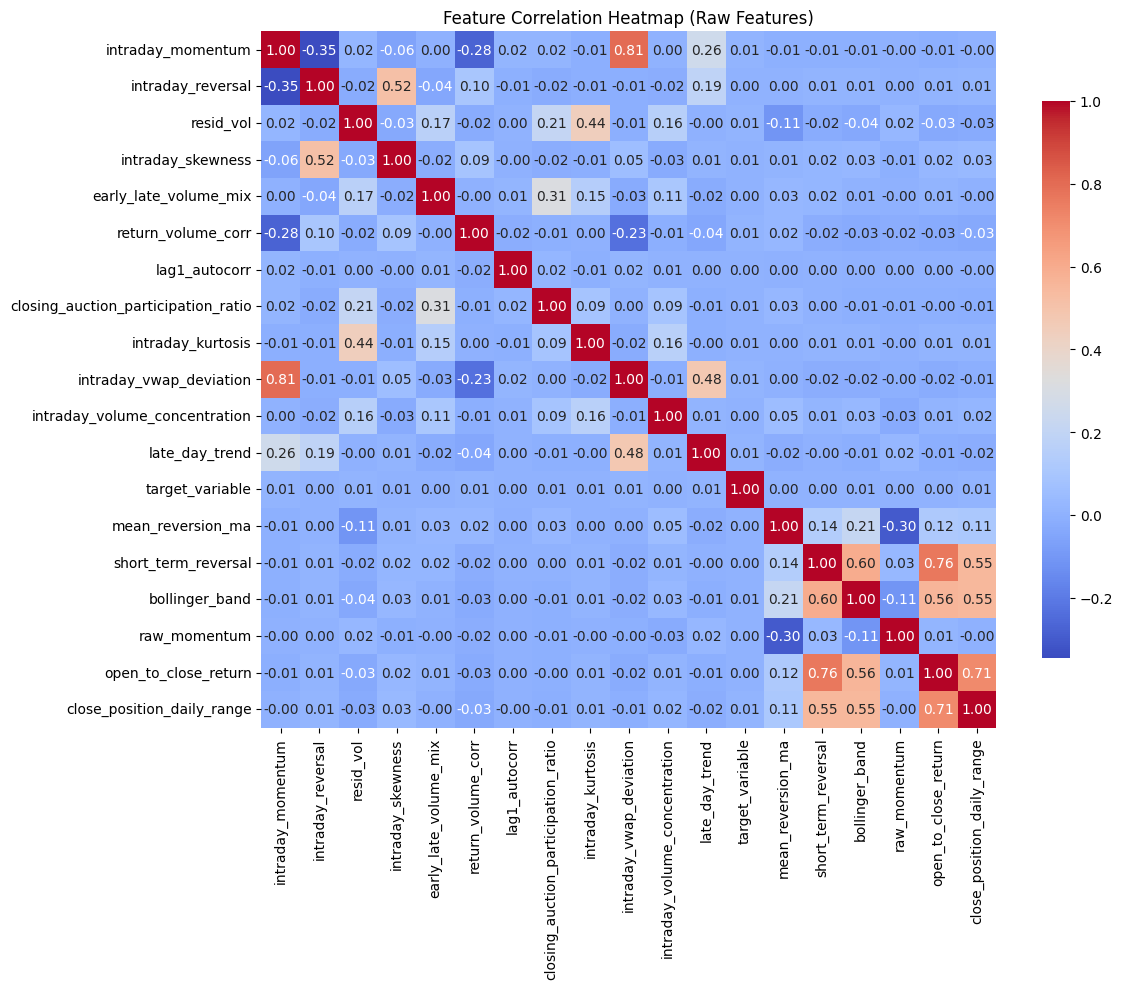

In [95]:
# lets work with the unfiltered data and see how the features relate to each other and the target
import seaborn as sns
plt.figure(figsize=(12, 10))
num_cols = df_raw_train_clean.select_dtypes(include="number").columns
corr = df_raw_train_clean[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar_kws={"shrink": .8})
plt.title("Feature Correlation Heatmap (Raw Features)")
plt.tight_layout()
plt.show()

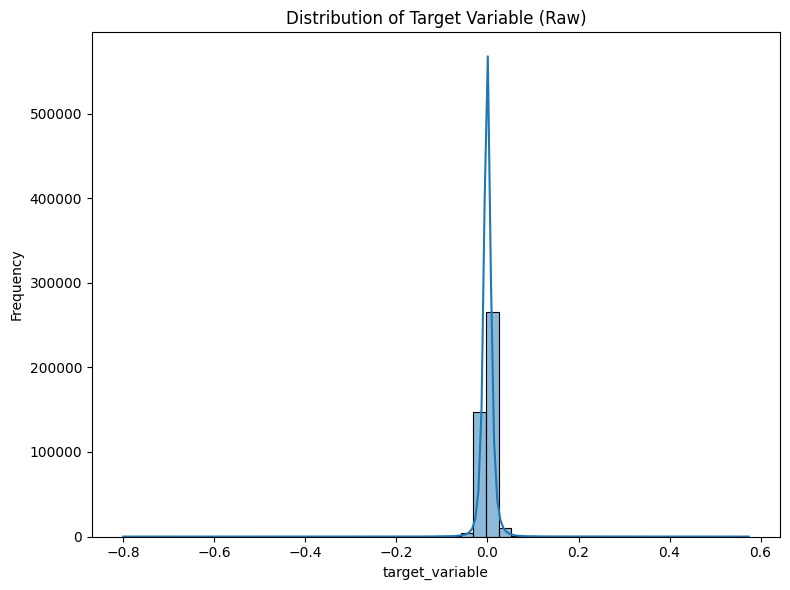

In [96]:
#lets look at the distribution of the target variable
plt.figure(figsize=(8, 6))
sns.histplot(df_raw_train_clean["target_variable"], bins=50, kde=True)
plt.title("Distribution of Target Variable (Raw)")
plt.xlabel("target_variable")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


In [97]:
# Looks like there are some very big outliers
#lets diagnose the outliers by looking at the top 10 largest values of the target variable
top_outliers = df_raw_train_clean["target_variable"].nlargest(10)
print("Top 10 largest target_variable values:")
print(top_outliers.to_string())

Top 10 largest target_variable values:
Date
2010-08-18    0.573907
2013-04-18    0.549168
2012-05-04    0.535720
2013-06-28    0.487968
2013-04-08    0.421565
2012-01-24    0.411549
2013-01-23    0.396577
2012-08-07    0.391040
2011-03-09    0.382956
2012-11-13    0.341313


In [98]:

# lets look at the MAD and std of target variables to see how extreme these outliers are
target = df_raw_train_clean["target_variable"]
target_mad = (target - target.median()).abs().median()
target_std = target.std()

print(f"\nTarget variable MAD: {target_mad:.4f}")
print(f"Target variable STD: {target_std:.4f}")
print(f"Target variable STD: {target_std:.4f}")


Target variable MAD: 0.0058
Target variable STD: 0.0142
Target variable STD: 0.0142


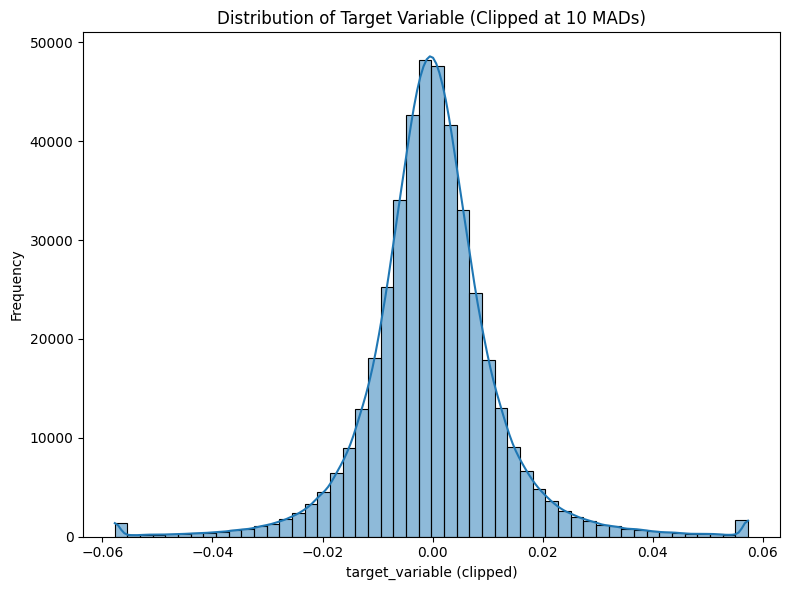

In [99]:
# lets clip the target variable at 10 MADs on both sides and see how the distribution looks
mad_clip = 10 * target_mad
target_clipped = target.clip(lower=target.median() - mad_clip, upper=target.median() + mad_clip)
plt.figure(figsize=(8, 6))
sns.histplot(target_clipped, bins=50, kde=True)
plt.title("Distribution of Target Variable (Clipped at 10 MADs)")
plt.xlabel("target_variable (clipped)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Fold 1: train 2010-2010 (64,290 rows) → val 2011 (124,154 rows)
Fold 2: train 2010-2011 (188,444 rows) → val 2012 (121,161 rows)
Fold 3: train 2010-2012 (309,605 rows) → val 2013 (122,150 rows)

TARGET CLIPPING THRESHOLD COMPARISON (Ridge α=1, raw features, 3-fold expanding CV on TRAIN)


,Threshold,Rows Clipped,% Clipped,Train Skew,Train Kurt,CV MSE (mean),CV Pearson IC,CV Spearman IC,Spearman IC std
0,3 MAD,47554,11.014,0.021,-0.474,0.000205,0.0161,0.0202,0.0024
1,5 MAD,15167,3.513,0.070,0.890,0.000205,0.0164,0.0198,0.0021
2,7 MAD,6649,1.540,0.115,2.379,0.000205,0.0164,0.0195,0.0018
3,10 MAD,2778,0.643,0.150,4.814,0.000205,0.0162,0.0193,0.0016
4,15 MAD,1062,0.246,0.177,9.430,0.000205,0.0159,0.0190,0.0014
5,20 MAD,530,0.123,0.160,14.663,0.000205,0.0158,0.0188,0.0014
6,None,0,0.000,-0.696,124.709,0.000205,0.0154,0.0183,0.0016


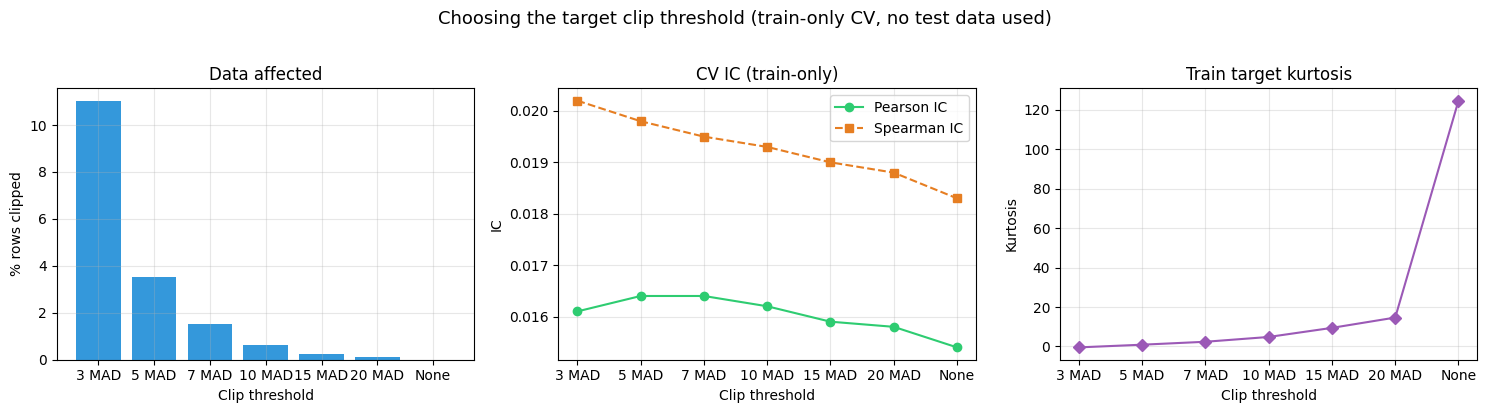


→ Best CV Spearman IC: 3 MAD (IC = 0.0202 ± 0.0024)


In [100]:
# ── Compare MAD clip thresholds using TRAIN-ONLY time-series CV ─────────
# We use expanding-window CV on the training set (2010-2013) so we never
# peek at the test set.  Each fold trains on years [start..y] and validates
# on year y+1.  Folds: train 2010→val 2011, train 2010-11→val 2012,
# train 2010-12→val 2013.

from sklearn.linear_model import Ridge
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

thresholds = [3, 5, 7, 10, 15, 20, None]  # None = no clipping
med = target.median()

# Build time-series CV splits from training data only
train_dates = pd.to_datetime(df_raw_train_clean.index)
train_years = train_dates.year
unique_years = sorted(train_years.unique())  # [2010, 2011, 2012, 2013]

# Expanding window folds: train on years[:i], validate on years[i]
folds = []
for i in range(1, len(unique_years)):
    train_mask_cv = train_years < unique_years[i]
    val_mask_cv   = train_years == unique_years[i]
    tr = np.asarray(train_mask_cv)
    va = np.asarray(val_mask_cv)
    folds.append((tr, va))
    print(f"Fold {i}: train {unique_years[0]}-{unique_years[i-1]} "
          f"({tr.sum():,} rows) → val {unique_years[i]} "
          f"({va.sum():,} rows)")

X_all = df_raw_train_clean[feature_cols].values
y_all = target.values

results = []
for t in thresholds:
    label = f"{t} MAD" if t else "None"

    if t is not None:
        clip_val = t * target_mad
        y_clipped_full = np.clip(y_all, med - clip_val, med + clip_val)
        n_clipped = int((y_all != y_clipped_full).sum())
        pct_clipped = n_clipped / len(y_all) * 100
    else:
        y_clipped_full = y_all.copy()
        n_clipped = 0
        pct_clipped = 0.0

    fold_pearson = []
    fold_spearman = []
    fold_mse = []

    for train_idx, val_idx in folds:
        X_tr, y_tr = X_all[train_idx], y_clipped_full[train_idx]
        X_va, y_va = X_all[val_idx], y_all[val_idx]  # validate on RAW target

        model = Ridge(alpha=1.0)
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_va)

        fold_mse.append(float(np.mean((y_va - y_pred) ** 2)))
        fold_pearson.append(float(np.corrcoef(y_va, y_pred)[0, 1]))
        fold_spearman.append(float(spearmanr(y_va, y_pred).correlation))

    # Distribution stats of clipped target
    skew = float(pd.Series(y_clipped_full).skew())
    kurt = float(pd.Series(y_clipped_full).kurtosis())

    results.append({
        "Threshold": label,
        "Rows Clipped": n_clipped,
        "% Clipped": round(pct_clipped, 3),
        "Train Skew": round(skew, 3),
        "Train Kurt": round(kurt, 3),
        "CV MSE (mean)": round(np.mean(fold_mse), 6),
        "CV Pearson IC": round(np.mean(fold_pearson), 4),
        "CV Spearman IC": round(np.mean(fold_spearman), 4),
        "Spearman IC std": round(np.std(fold_spearman), 4),
    })

results_df = pd.DataFrame(results)
print(f"\n{'='*95}")
print("TARGET CLIPPING THRESHOLD COMPARISON (Ridge α=1, raw features, 3-fold expanding CV on TRAIN)")
print(f"{'='*95}")
display(results_df)

# Visual
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
x_labels = [r["Threshold"] for r in results]
x = range(len(x_labels))

axes[0].bar(x, results_df["% Clipped"], color="#3498db")
axes[0].set_xticks(list(x)); axes[0].set_xticklabels(x_labels)
axes[0].set_ylabel("% rows clipped"); axes[0].set_title("Data affected")

axes[1].plot(list(x), results_df["CV Pearson IC"], "o-", label="Pearson IC", color="#2ecc71")
axes[1].plot(list(x), results_df["CV Spearman IC"], "s--", label="Spearman IC", color="#e67e22")
axes[1].set_xticks(list(x)); axes[1].set_xticklabels(x_labels)
axes[1].set_ylabel("IC"); axes[1].set_title("CV IC (train-only)")
axes[1].legend()

axes[2].plot(list(x), results_df["Train Kurt"], "D-", color="#9b59b6")
axes[2].set_xticks(list(x)); axes[2].set_xticklabels(x_labels)
axes[2].set_ylabel("Kurtosis"); axes[2].set_title("Train target kurtosis")

for ax in axes:
    ax.set_xlabel("Clip threshold")
    ax.grid(True, alpha=0.3)
fig.suptitle("Choosing the target clip threshold (train-only CV, no test data used)", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

best_idx = results_df["CV Spearman IC"].abs().idxmax()
print(f"\n→ Best CV Spearman IC: {results_df.loc[best_idx, 'Threshold']} "
      f"(IC = {results_df.loc[best_idx, 'CV Spearman IC']:.4f} ± {results_df.loc[best_idx, 'Spearman IC std']:.4f})")

In [101]:
# lets save the target clipper as we would be using this in the modeling pipeline to ensure consistency
import joblib
clipper_path = FEATURE_DATA_DIR / "target_clipper.joblib"
joblib.dump({"median": target.median(), "mad_clip": mad_clip}, clipper_path)
print(f"✓ Saved target clipper to {clipper_path}")

✓ Saved target clipper to /Users/chaithanyapakala/Downloads/MTH9899_ProjectFinal/feature_data/target_clipper.joblib


Date
2010-06-25   -0.001544
2010-06-25    0.004446
2010-06-25    0.007429
2010-06-25    0.003164
2010-06-25    0.004248
                ...   
2013-12-31   -0.015143
2013-12-31   -0.002394
2013-12-31    0.002028
2013-12-31    0.003892
2013-12-31    0.002174
Name: intraday_momentum, Length: 431755, dtype: float64

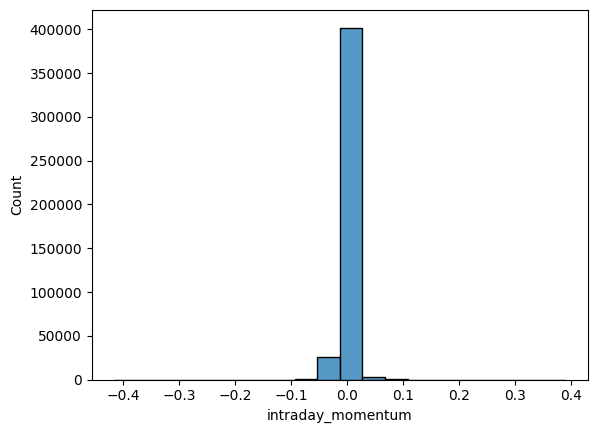

In [102]:
#lets do the same thing we have done to targets, to each of the features ie., look at their distributions to see how we ca clip them

feat1_series = df_raw_train_clean['intraday_momentum']
sns.histplot(feat1_series, bins = 20)
feat1_series
#lets look at the top 10 

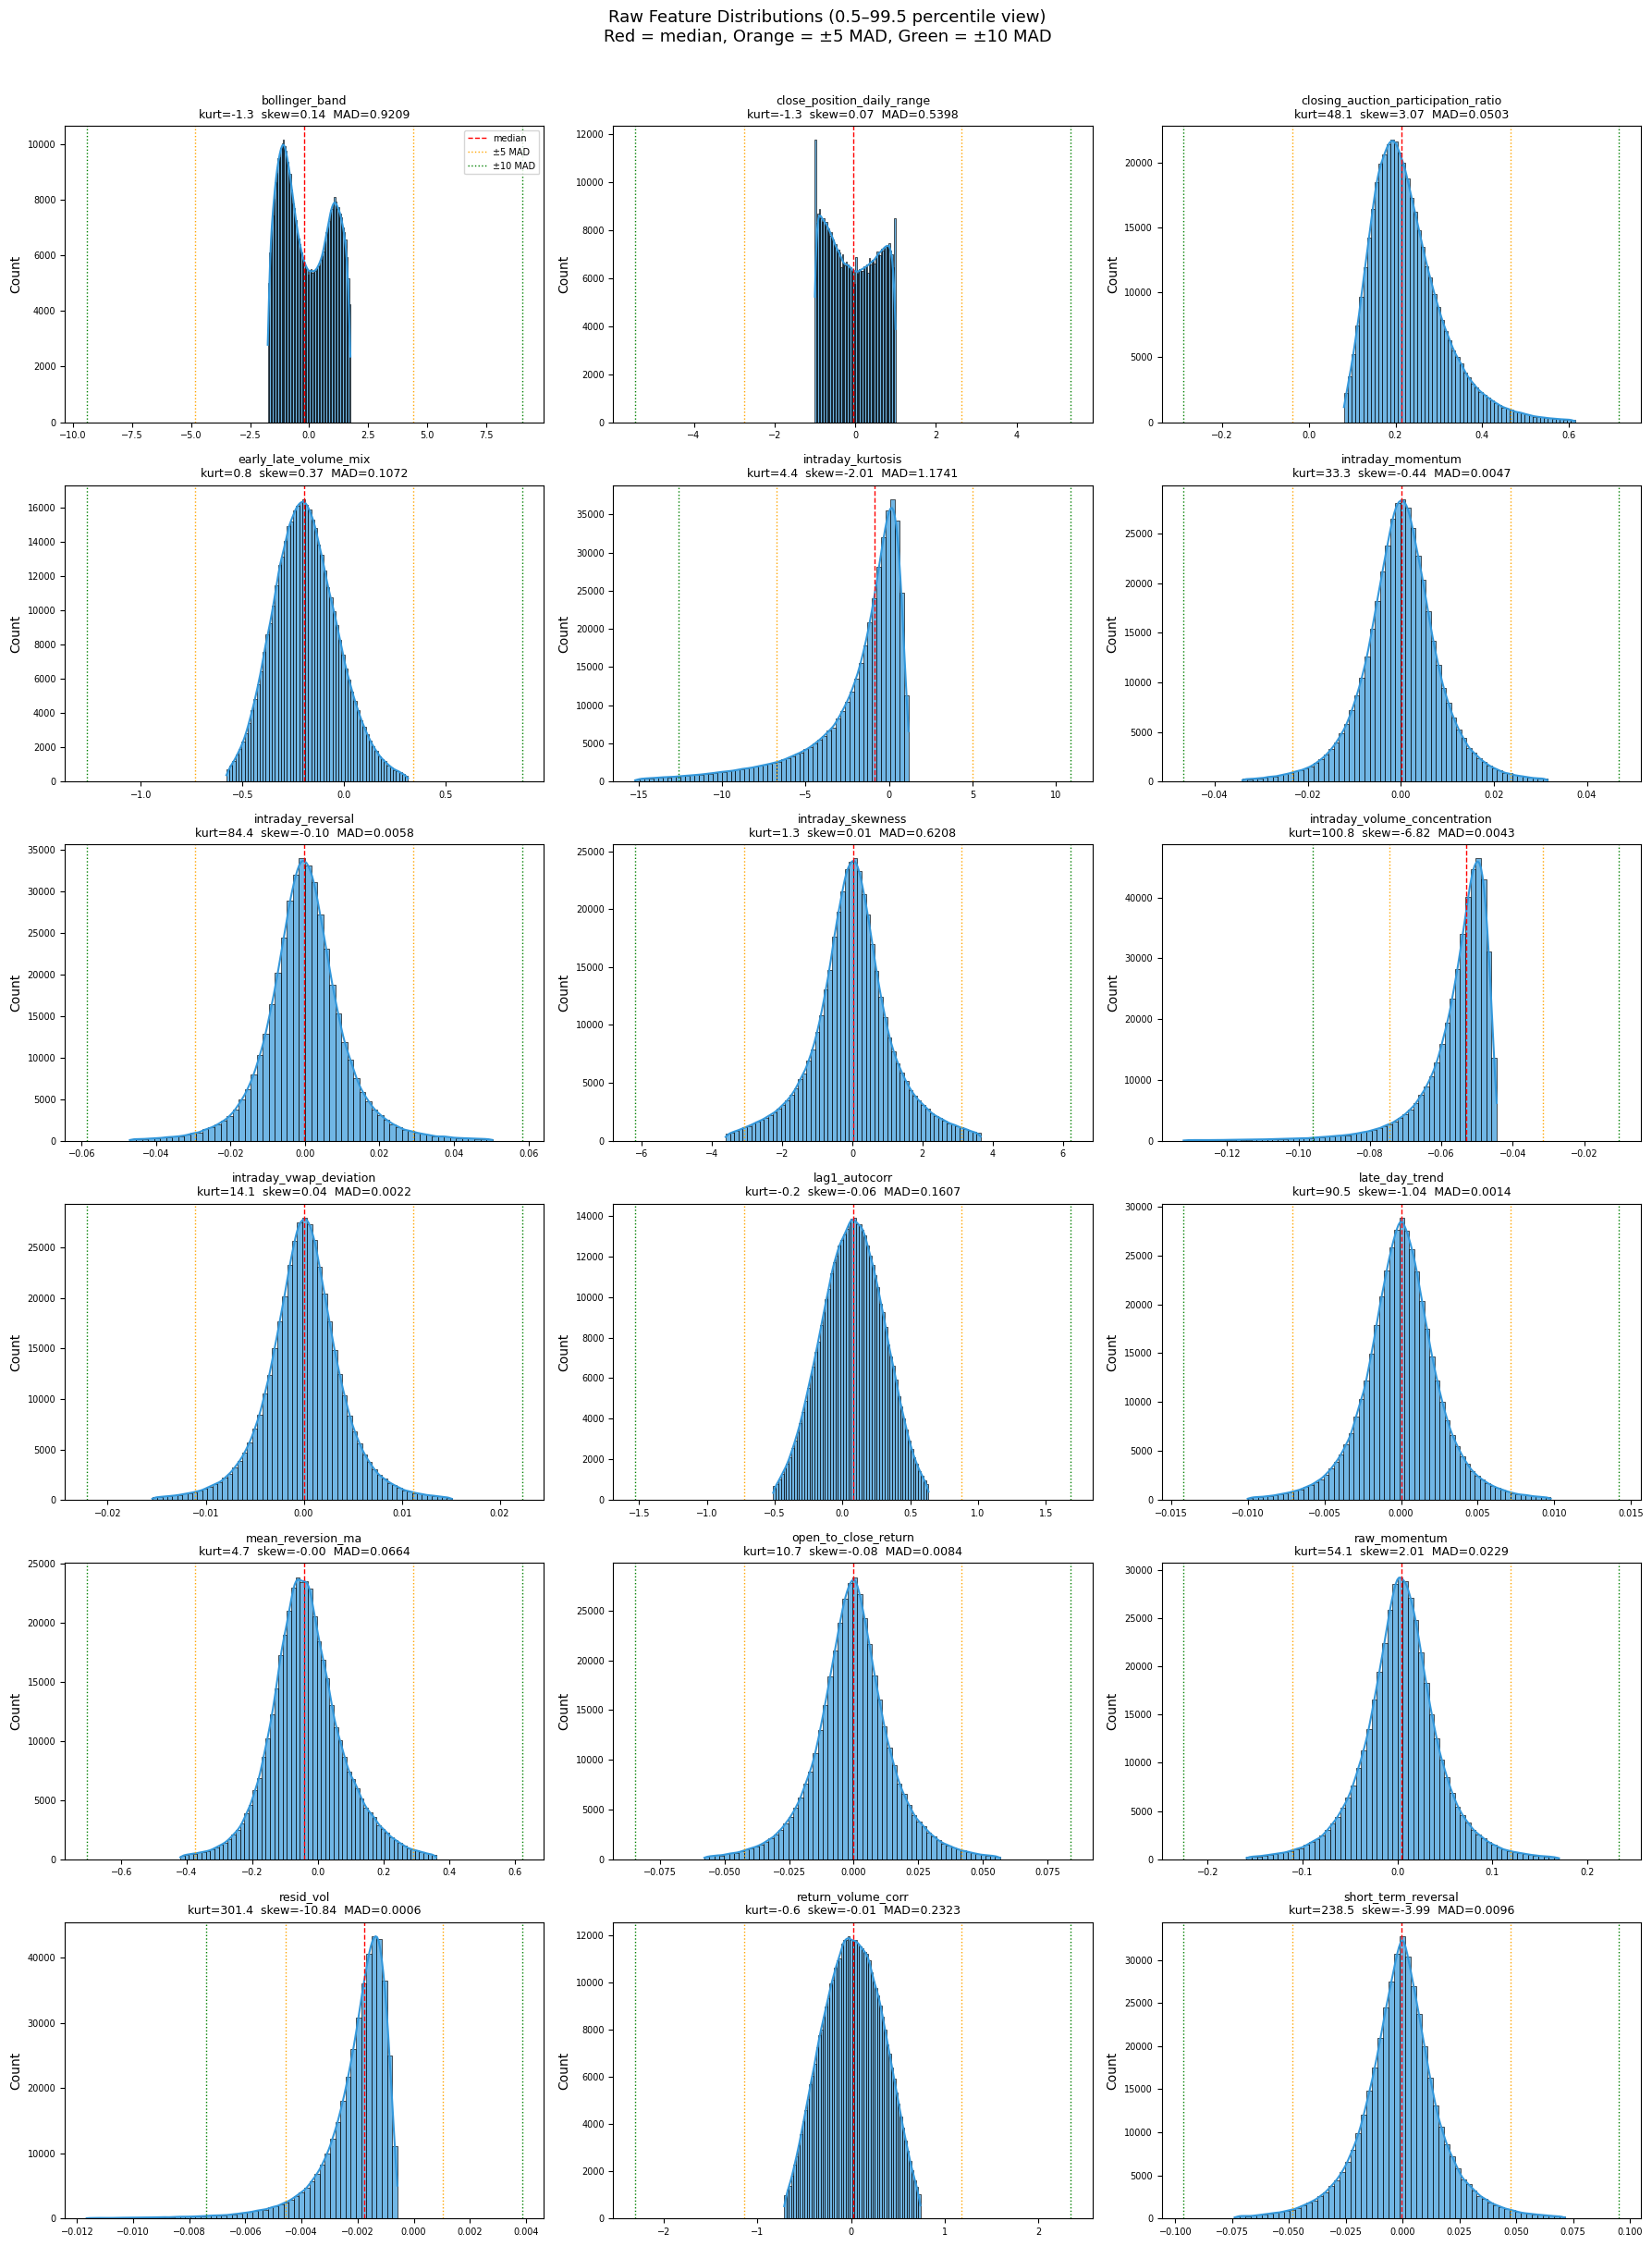


FEATURE OUTLIER SUMMARY (raw unfiltered features)


,% outside 10 MAD,% outside 3 MAD,% outside 5 MAD,kurtosis,skew
feature,,,,,
resid_vol,1.48,11.16,5.21,301.4,-10.84
short_term_reversal,0.42,11.71,3.42,238.5,-3.99
intraday_volume_concentration,1.75,12.11,5.95,100.8,-6.82
late_day_trend,0.30,10.34,2.80,90.5,-1.04
intraday_reversal,0.63,10.92,3.44,84.4,-0.10
raw_momentum,0.35,10.93,2.98,54.1,2.01
closing_auction_participation_ratio,0.22,7.53,2.19,48.1,3.07
intraday_momentum,0.31,10.37,2.82,33.3,-0.44
intraday_vwap_deviation,0.27,10.13,2.74,14.1,0.04


In [103]:

# ── Feature distribution grid (raw unfiltered features) ─────────────────
# Plot each feature's distribution + key outlier stats to guide clipping

import matplotlib.pyplot as plt
import seaborn as sns

n_feats = len(feature_cols)
ncols = 3
nrows = (n_feats + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows))
axes = axes.flatten()

feat_stats = []

for i, col in enumerate(sorted(feature_cols)):
    ax = axes[i]
    series = df_raw_train_clean[col].dropna()
    
    # Compute stats
    med = series.median()
    mad = (series - med).abs().median()
    kurt = float(series.kurtosis())
    skew = float(series.skew())
    p01, p99 = series.quantile(0.01), series.quantile(0.99)
    
    # Clip for plotting only (so histogram isn't crushed by outliers)
    plot_lo, plot_hi = series.quantile(0.005), series.quantile(0.995)
    series_plot = series[(series >= plot_lo) & (series <= plot_hi)]
    
    sns.histplot(series_plot, bins=60, kde=True, ax=ax, color="#3498db", alpha=0.7)
    
    # Mark median and ±5 MAD lines
    ax.axvline(med, color="red", ls="--", lw=1, label="median")
    if mad > 0:
        ax.axvline(med - 5 * mad, color="orange", ls=":", lw=1, label="±5 MAD")
        ax.axvline(med + 5 * mad, color="orange", ls=":", lw=1)
        ax.axvline(med - 10 * mad, color="green", ls=":", lw=1, label="±10 MAD")
        ax.axvline(med + 10 * mad, color="green", ls=":", lw=1)
    
    ax.set_title(f"{col}\nkurt={kurt:.1f}  skew={skew:.2f}  MAD={mad:.4f}", fontsize=9)
    ax.set_xlabel("")
    ax.tick_params(labelsize=7)
    if i == 0:
        ax.legend(fontsize=7)
    
    # Count how many rows fall outside various MAD thresholds
    for t in [3, 5, 10]:
        if mad > 0:
            outside = ((series < med - t * mad) | (series > med + t * mad)).sum()
        else:
            outside = 0
        feat_stats.append({"feature": col, "threshold": f"{t} MAD",
                           "n_outside": outside,
                           "pct_outside": round(outside / len(series) * 100, 2),
                           "kurtosis": round(kurt, 1),
                           "skew": round(skew, 2)})

# Hide unused axes
for j in range(n_feats, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Raw Feature Distributions (0.5–99.5 percentile view)\n"
             "Red = median, Orange = ±5 MAD, Green = ±10 MAD",
             fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

# Summary table
feat_stats_df = pd.DataFrame(feat_stats)
pivot = feat_stats_df.pivot_table(index="feature", columns="threshold",
                                   values=["pct_outside"], aggfunc="first")
pivot.columns = [f"% outside {c[1]}" for c in pivot.columns]
pivot["kurtosis"] = feat_stats_df.groupby("feature")["kurtosis"].first()
pivot["skew"] = feat_stats_df.groupby("feature")["skew"].first()
pivot = pivot.sort_values("kurtosis", ascending=False)

print("\n" + "=" * 80)
print("FEATURE OUTLIER SUMMARY (raw unfiltered features)")
print("=" * 80)
display(pivot)


In [104]:

# ── Apply 5 MAD clipping to all features + target, save clipping params ──
import joblib

CLIP_MADS = 5

# 1. Compute per-feature clipping params from TRAIN only (no look-ahead)
feature_clip_params = {}
for col in feature_cols:
    series = df_raw_train_clean[col].dropna()
    med = float(series.median())
    mad = float((series - med).abs().median())
    clip_val = CLIP_MADS * mad
    lo = med - clip_val
    hi = med + clip_val
    n_before = len(series)
    n_clipped = int(((series < lo) | (series > hi)).sum())
    feature_clip_params[col] = {"median": med, "mad": mad, "clip_lo": lo, "clip_hi": hi}
    print(f"  {col:42s}  med={med:+.5f}  MAD={mad:.5f}  "
          f"clip=[{lo:+.5f}, {hi:+.5f}]  clipped={n_clipped:,} ({n_clipped/n_before*100:.2f}%)")

# 2. Clip features in train and test
df_raw_train_clipped = df_raw_train_clean.copy()
df_raw_test_clipped  = df_raw_test_clean.copy()

for col, params in feature_clip_params.items():
    df_raw_train_clipped[col] = df_raw_train_clipped[col].clip(lower=params["clip_lo"],
                                                                upper=params["clip_hi"])
    df_raw_test_clipped[col]  = df_raw_test_clipped[col].clip(lower=params["clip_lo"],
                                                               upper=params["clip_hi"])

# 3. Clip target at 5 MAD (updating from 10 MAD)
target_med = float(target.median())
target_clip_val = CLIP_MADS * target_mad
target_clip_params = {"median": target_med, "mad": float(target_mad),
                      "clip_lo": target_med - target_clip_val,
                      "clip_hi": target_med + target_clip_val}

df_raw_train_clipped["target_variable"] = df_raw_train_clipped["target_variable"].clip(
    lower=target_clip_params["clip_lo"], upper=target_clip_params["clip_hi"])
# NOTE: do NOT clip test target — we evaluate on raw actuals

print(f"\n  {'target_variable':42s}  med={target_med:+.5f}  MAD={target_mad:.5f}  "
      f"clip=[{target_clip_params['clip_lo']:+.5f}, {target_clip_params['clip_hi']:+.5f}]")

# 4. Save all clipping params to joblib
all_clip_params = {
    "clip_mads": CLIP_MADS,
    "features": feature_clip_params,
    "target": target_clip_params,
}
clipper_path = FEATURE_DATA_DIR / "clip_params.joblib"
joblib.dump(all_clip_params, clipper_path)
print(f"\n✓ Saved clipping params ({len(feature_clip_params)} features + target) → {clipper_path}")

# 5. Quick before/after kurtosis comparison
print(f"\n{'='*80}")
print(f"KURTOSIS BEFORE vs AFTER 5-MAD CLIPPING (train)")
print(f"{'='*80}")
print(f"{'Feature':<42} {'Before':>10} {'After':>10} {'Change':>10}")
print(f"{'-'*72}")
for col in sorted(feature_cols):
    k_before = float(df_raw_train_clean[col].kurtosis())
    k_after  = float(df_raw_train_clipped[col].kurtosis())
    print(f"{col:<42} {k_before:>10.1f} {k_after:>10.1f} {k_after - k_before:>+10.1f}")

k_before = float(df_raw_train_clean["target_variable"].kurtosis())
k_after  = float(df_raw_train_clipped["target_variable"].kurtosis())
print(f"{'target_variable':<42} {k_before:>10.1f} {k_after:>10.1f} {k_after - k_before:>+10.1f}")


  intraday_momentum                           med=+0.00011  MAD=0.00468  clip=[-0.02330, +0.02352]  clipped=12,170 (2.82%)
  intraday_reversal                           med=-0.00017  MAD=0.00585  clip=[-0.02941, +0.02907]  clipped=14,867 (3.44%)
  resid_vol                                   med=-0.00176  MAD=0.00056  clip=[-0.00457, +0.00105]  clipped=22,506 (5.21%)
  intraday_skewness                           med=+0.01493  MAD=0.62082  clip=[-3.08918, +3.11904]  clipped=11,704 (2.71%)
  early_late_volume_mix                       med=-0.19526  MAD=0.10719  clip=[-0.73118, +0.34067]  clipped=1,860 (0.43%)
  return_volume_corr                          med=+0.01947  MAD=0.23228  clip=[-1.14192, +1.18086]  clipped=0 (0.00%)
  lag1_autocorr                               med=+0.07672  MAD=0.16067  clip=[-0.72662, +0.88005]  clipped=24 (0.01%)
  closing_auction_participation_ratio         med=+0.21356  MAD=0.05028  clip=[-0.03785, +0.46498]  clipped=9,468 (2.19%)
  intraday_kurtosis        

## Model 2: Random Forest & Model 3: XGBoost

### Model Selection Design: Simple Train/Valid Split

- **Train/Valid split:** 2010–2013 split into train/valid (80/20 by date)
- **Grid search:**
    - XGBoost:
        ```python
        xgb_param_grid = {
            "n_estimators":     [200, 500],
            "max_depth":        [3, 5],
            "learning_rate":    [0.01, 0.05],
            "subsample":        [0.7, 1.0],
            "colsample_bytree": [0.5, 0.8],
        }
        ```
    - Random Forest:
        ```python
        rf_param_grid = {
            "n_estimators":     [100, 200],
            "max_depth":        [3, 5],
            "min_samples_leaf": [50, 100],
            "max_features":     ["sqrt"],
        }
        ```
- **Best HPs** found on validation set, then final evaluation on 2014 OOS.

**No walk-forward or purged CV.**

## Feature Normalization

We apply a **two-stage normalization** to the clipped features:

### Stage 1 — Global (Time-Series) Standardization
For each feature, subtract the **training-set mean** and divide by the **training-set standard deviation**:
$$z_{i,t}^{(1)} = \frac{x_{i,t} - \hat{\mu}_i}{\hat{\sigma}_i}$$
where $\hat{\mu}_i$ and $\hat{\sigma}_i$ are computed from the **training set only** (no look-ahead bias).

**Why?** Different features have vastly different scales (e.g., `resid_vol` ∈ [0, 0.1] vs `intraday_volume_concentration` ∈ [0, 100]). Global standardization puts all features on a comparable scale, which is critical for Ridge regression and improves convergence for tree-based models.

### Stage 2 — Cross-Sectional (Per-Date) Rank-Normalization
On each trading day, we rank all stocks for each feature and map the ranks to a standard normal via the inverse CDF:
$$z_{i,t}^{(2)} = \Phi^{-1}\!\left(\frac{\text{rank}(z_{i,t}^{(1)}) - 0.5}{N_t}\right)$$
where $N_t$ is the number of stocks on day $t$ and $\Phi^{-1}$ is the standard normal quantile function.

**Why cross-sectional normalization?**
1. **Removes temporal drift**: Market regimes change (e.g., volatility was higher in 2010-2011 than 2012-2013). Cross-sectional ranking ensures the model sees *relative* signal strength, not absolute levels.
2. **Handles non-stationarity**: Even after clipping, some features have heavy tails or skew that changes over time. Rank-normalization produces an approximately Gaussian cross-section every day.
3. **Standard in quant finance**: Cross-sectional signals are the foundation of relative-value strategies — we care about *which stocks are extreme today*, not whether today's overall level is higher than last month.
4. **No look-ahead bias**: Each day's ranking uses only that day's cross-section.

### Normalization parameters saved to:
`feature_data/norm_params.joblib` — contains per-feature `{mean, std}` from Stage 1 (train-derived). Stage 2 is applied on-the-fly (no stored params needed, since it uses only same-day cross-sectional ranks).

In [105]:
df_raw_train_clipped

,Id,intraday_momentum,intraday_reversal,resid_vol,intraday_skewness,early_late_volume_mix,return_volume_corr,lag1_autocorr,closing_auction_participation_ratio,intraday_kurtosis,intraday_vwap_deviation,intraday_volume_concentration,late_day_trend,target_variable,mean_reversion_ma,short_term_reversal,bollinger_band,raw_momentum,open_to_close_return,close_position_daily_range
Date,,,,,,,,,,,,,,,,,,,,
2010-06-25,BBG000B9WH86,-0.001544,0.000895,-0.001909,0.255064,-0.116972,-0.028402,-0.172892,0.169643,-0.701047,-0.000163,-0.048255,-0.000439,0.005181,0.165521,0.027997,0.869953,-0.025884,0.017683,0.733333
2010-06-25,BBG000B9WJ73,0.004446,0.003876,-0.002301,-0.037608,-0.209490,0.171905,0.159566,0.462146,1.183963,0.002893,-0.046445,0.004665,-0.007089,0.082067,0.045992,1.550580,-0.048676,0.041860,0.747961
2010-06-25,BBG000B9XRY4,0.007429,-0.010483,-0.001410,-0.926621,-0.338428,0.135472,0.329232,0.135248,-1.701839,0.004487,-0.057439,-0.001125,0.004783,-0.158318,0.007270,1.157417,0.054527,0.007380,0.646712
2010-06-25,BBG000B9XYV2,0.003164,0.003964,-0.001827,0.084233,-0.171350,0.147372,0.058800,0.371228,-0.446883,0.004334,-0.044311,0.004360,0.028565,-0.023331,0.026169,1.580427,-0.000451,0.022013,0.936000
2010-06-25,BBG000B9ZXB4,0.004248,0.006809,-0.001197,-0.349805,-0.029903,-0.582203,0.311901,0.359551,-0.297025,0.003130,-0.045901,-0.000934,-0.000918,0.080506,0.002103,1.029400,-0.003737,-0.001688,0.269841
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2013-12-31,BBG002S5ZRF9,-0.015143,0.020385,-0.002497,1.036345,-0.261560,0.104377,0.037641,0.157437,-1.647751,-0.003598,-0.055569,0.002614,0.016823,-0.160306,-0.011860,-0.529319,0.085089,-0.009747,-0.400458
2013-12-31,BBG0035LY913,-0.002394,0.006734,-0.001821,-0.308612,-0.042322,0.417111,0.278531,0.271168,-1.853849,-0.001729,-0.074509,-0.000340,-0.006078,-0.063317,-0.010152,-0.797520,0.015429,-0.007312,-0.826087
2013-12-31,BBG003641015,0.002028,0.002424,-0.001495,-0.809649,0.219363,-0.363781,-0.080887,0.301708,-0.315172,0.001273,-0.074509,0.001105,-0.008868,0.012252,0.013852,-0.024558,0.019676,0.013852,0.687500


In [106]:

# work with a different set of df_train and test

# df_raw_train_clipped = df_train_clean.copy()
# df_raw_test_clipped  = df_test_clean.copy()


import joblib
from scipy.stats import norm as sp_norm

norm_params = {}
for col in feature_cols:
    series = df_train_clean[col].dropna()
    mu  = float(series.mean())
    std = float(series.std())
    norm_params[col] = {"mean": mu, "std": std}

print("Stage 1 — Global standardization params (from train):")
print(f"{'Feature':<42} {'Mean':>12} {'Std':>12}")
print(f"{'-'*66}")
for col in sorted(feature_cols):
    p = norm_params[col]
    print(f"{col:<42} {p['mean']:>12.6f} {p['std']:>12.6f}")




# Apply Stage 1 to train and test
df_train_s1 = df_raw_train_clipped.copy()
df_test_s1  = df_raw_test_clipped.copy()



for col in feature_cols:
    mu, std = norm_params[col]["mean"], norm_params[col]["std"]
    if std > 1e-12:
        df_train_s1[col] = (df_train_s1[col] - mu) / std
        df_test_s1[col]  = (df_test_s1[col] - mu) / std
    else:
        # Constant feature — set to 0
        df_train_s1[col] = 0.0
        df_test_s1[col]  = 0.0

print(f"\n✓ Stage 1 applied. Train: {df_train_s1.shape}  |  Test: {df_test_s1.shape}")
print(f"\nTrain feature stats after Stage 1 (should be ~mean=0, std=1):")
display(df_train_s1[feature_cols].describe().loc[["mean", "std", "min", "max"]].T.round(4))

Stage 1 — Global standardization params (from train):
Feature                                            Mean          Std
------------------------------------------------------------------
bollinger_band                                -0.092772     1.032210
close_position_daily_range                     0.018707     0.157356
closing_auction_participation_ratio            0.230139     0.094599
early_late_volume_mix                         -0.005491     0.050336
intraday_kurtosis                             -0.038047     0.498384
intraday_momentum                             -0.000442     0.004755
intraday_reversal                              0.000141     0.010345
intraday_skewness                             -0.090939     0.554375
intraday_volume_concentration                 -0.056567     0.014018
intraday_vwap_deviation                       -0.000184     0.002054
lag1_autocorr                                 -0.000195     0.046566
late_day_trend                                 0.00

,mean,std,min,max
intraday_momentum,0.0979,1.7747,-4.8066,5.0393
intraday_reversal,-0.0171,1.0385,-2.8562,2.7960
resid_vol,-0.8007,0.5053,-2.0751,0.1555
intraday_skewness,0.1912,2.1124,-5.4083,5.7903
early_late_volume_mix,-3.6143,3.2648,-14.4169,6.8770
return_volume_corr,0.3866,6.6461,-20.8324,20.8326
lag1_autocorr,1.5965,4.9814,-15.6000,18.9034
closing_auction_participation_ratio,-0.0253,0.8750,-2.4328,2.4824
intraday_kurtosis,-3.2592,4.6393,-13.4191,3.4048
intraday_vwap_deviation,0.1090,1.9382,-5.2870,5.5289


In [43]:
# ── Stage 2: Cross-sectional rank-normalization (per date) ──────────────
# For each date, rank stocks within each feature, then map to N(0,1) via
# the inverse CDF.  This removes temporal drift and non-stationarity.

def cross_sectional_rank_norm(df, feature_cols):
    """
    For each date, rank each feature across stocks and map to N(0,1).
    Uses (rank - 0.5) / N to avoid ±inf at the extremes.
    """
    df_out = df.copy()
    dates = df_out.index  # DatetimeIndex (Date)

    for col in feature_cols:
        # groupby date, rank within each date
        ranked = df_out.groupby(dates)[col].rank(method="average", na_option="keep")
        # count non-NaN per date for scaling
        counts = df_out.groupby(dates)[col].transform("count")
        # Map to uniform (0, 1) then to N(0, 1) via inverse CDF
        uniform = (ranked - 0.5) / counts
        df_out[col] = sp_norm.ppf(uniform)

    return df_out

print("Applying Stage 2 (cross-sectional rank-normalization)...")
df_train_norm = cross_sectional_rank_norm(df_train_s1, feature_cols)
print(f"  ✓ Train done: {df_train_norm.shape}")

df_test_norm = cross_sectional_rank_norm(df_test_s1, feature_cols)
print(f"  ✓ Test done:  {df_test_norm.shape}")

# Quick sanity check: per-date stats should be ~N(0,1)
sample_date = df_train_norm.index.unique()[500]
daily_slice = df_train_norm.loc[sample_date, feature_cols]
print(f"\nSanity check — stats on {sample_date.date()} ({len(daily_slice)} stocks):")
display(daily_slice.describe().loc[["mean", "std", "min", "max"]].T.round(3))

Applying Stage 2 (cross-sectional rank-normalization)...
  ✓ Train done: (431257, 20)
  ✓ Test done:  (121866, 20)

Sanity check — stats on 2012-06-25 (497 stocks):


,mean,std,min,max
intraday_momentum,0.002,0.496,-3.088,3.088
intraday_reversal,-0.011,0.571,-3.088,3.088
resid_vol,-0.055,0.535,-3.088,0.096
intraday_skewness,-0.022,0.575,-3.088,3.088
early_late_volume_mix,-0.029,0.429,-3.088,3.088
return_volume_corr,-0.009,0.457,-3.088,3.088
lag1_autocorr,0.010,0.485,-3.088,3.088
closing_auction_participation_ratio,0.000,1.000,-3.088,3.088
intraday_kurtosis,-0.029,0.429,-3.088,3.088
intraday_vwap_deviation,-0.005,0.512,-3.088,3.088


In [44]:
# ── Save normalization params + normalized data ─────────────────────────
import joblib

norm_save = {
    "stage1_params": norm_params,          # per-feature {mean, std} from train
    "stage2_method": "cross_sectional_rank_norm",  # for reproducibility
    "feature_cols": feature_cols,
    "notes": (
        "Stage 1: subtract train mean, divide by train std. "
        "Stage 2: per-date rank → inverse-normal CDF (no stored params needed). "
        "Apply Stage 1 first using saved params, then Stage 2 on-the-fly."
    ),
}
norm_path = FEATURE_DATA_DIR / "norm_params.joblib"
joblib.dump(norm_save, norm_path)
print(f"✓ Saved normalization params → {norm_path}")

# Also cache the fully normalized DataFrames as parquet for fast reload
norm_train_path = FEATURE_DATA_DIR / "feature_together" / "features_norm_train2.parquet" #2 is the inverted mad case
norm_test_path  = FEATURE_DATA_DIR / "feature_together" / "features_norm_test.parquet"
df_train_norm.to_parquet(norm_train_path)
df_test_norm.to_parquet(norm_test_path)
print(f"✓ Saved normalized train → {norm_train_path.name}  ({len(df_train_norm):,} rows)")
print(f"✓ Saved normalized test  → {norm_test_path.name}   ({len(df_test_norm):,} rows)")

✓ Saved normalization params → /Users/chaithanyapakala/Downloads/MTH9899_ProjectFinal/feature_data/norm_params.joblib
✓ Saved normalized train → features_norm_train2.parquet  (431,257 rows)
✓ Saved normalized test  → features_norm_test.parquet   (121,866 rows)


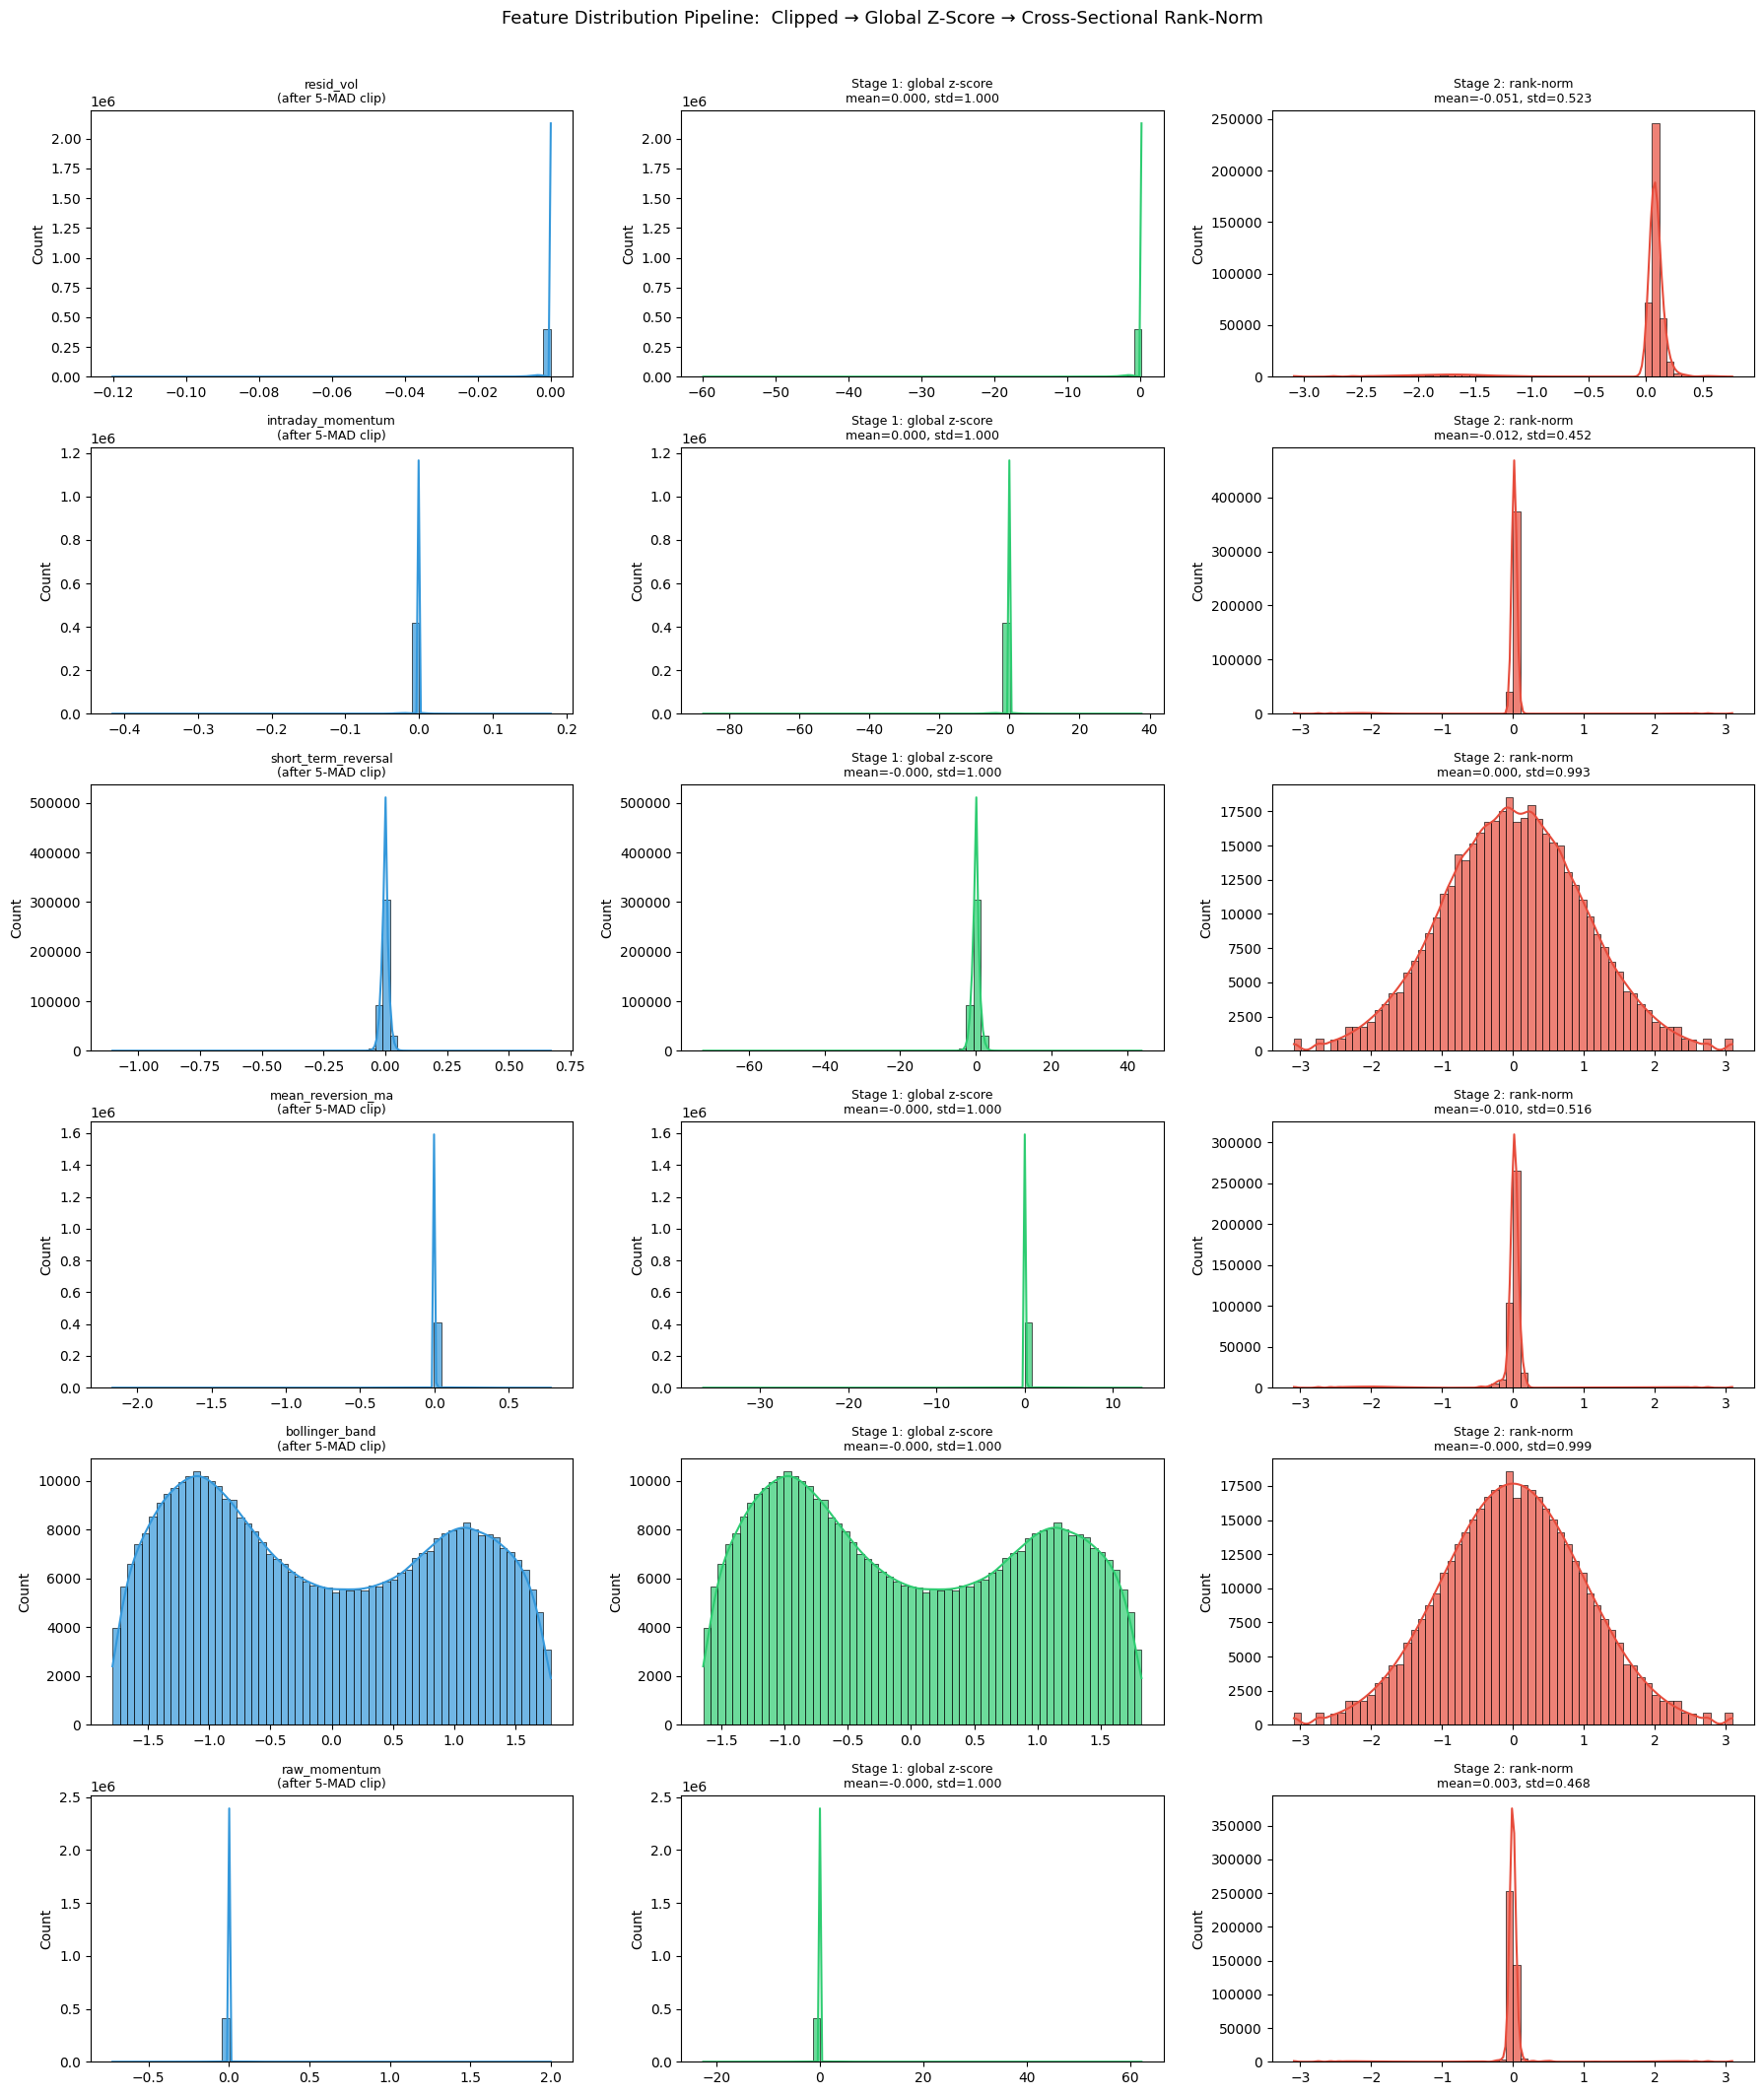


OVERALL NORMALIZATION STATS (train set)

Feature                             Clipped Skew    S1 Skew    S2 Skew  Clipped Kurt    S1 Kurt    S2 Kurt
----------------------------------------------------------------------------------------------------
bollinger_band                             0.142      0.142     -0.000          -1.3       -1.3       -0.0
close_position_daily_range                 3.922      3.922      1.182          28.8       28.8       26.8
closing_auction_participation_ratio        3.078      3.078      0.000          48.2       48.2       -0.0
early_late_volume_mix                     -9.466     -9.466     -3.735         115.0      115.0       43.6
intraday_kurtosis                        -17.717    -17.717     -2.265         388.3      388.3       48.3
intraday_momentum                        -11.273    -11.273     -1.309         390.5      390.5       27.9
intraday_reversal                         -0.309     -0.309      0.141         293.2      293.2       17.6
i

In [45]:
# ── Before vs After normalization: distribution comparison ──────────────
import matplotlib.pyplot as plt
import seaborn as sns


# Pick 6 representative features to show the transformation
show_cols = ["resid_vol", "intraday_momentum", "short_term_reversal",
             "mean_reversion_ma", "bollinger_band", "raw_momentum"]

fig, axes = plt.subplots(len(show_cols), 3, figsize=(18, 3.5 * len(show_cols)))

for i, col in enumerate(show_cols):
    # Column 1: Raw clipped
    ax1 = axes[i, 0]
    data1 = df_raw_train_clipped[col].dropna()
    sns.histplot(data1, bins=60, kde=True, ax=ax1, color="#3498db", alpha=0.7)
    ax1.set_title(f"{col}\n(after 5-MAD clip)", fontsize=9)
    ax1.set_xlabel("")

    # Column 2: After Stage 1 (global z-score)
    ax2 = axes[i, 1]
    data2 = df_train_s1[col].dropna()
    sns.histplot(data2, bins=60, kde=True, ax=ax2, color="#2ecc71", alpha=0.7)
    ax2.set_title(f"Stage 1: global z-score\nmean={data2.mean():.3f}, std={data2.std():.3f}", fontsize=9)
    ax2.set_xlabel("")

    # Column 3: After Stage 2 (cross-sectional rank-norm)
    ax3 = axes[i, 2]
    data3 = df_train_norm[col].dropna()
    # clip infinities for plotting (shouldn't exist but just in case)
    data3 = data3[np.isfinite(data3)]
    sns.histplot(data3, bins=60, kde=True, ax=ax3, color="#e74c3c", alpha=0.7)
    ax3.set_title(f"Stage 2: rank-norm\nmean={data3.mean():.3f}, std={data3.std():.3f}", fontsize=9)
    ax3.set_xlabel("")

fig.suptitle("Feature Distribution Pipeline:  Clipped → Global Z-Score → Cross-Sectional Rank-Norm",
             fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

# Overall stats summary
print(f"\n{'='*80}")
print("OVERALL NORMALIZATION STATS (train set)")
print(f"{'='*80}")
print(f"\n{'Feature':<35} {'Clipped Skew':>12} {'S1 Skew':>10} {'S2 Skew':>10}  "
      f"{'Clipped Kurt':>12} {'S1 Kurt':>10} {'S2 Kurt':>10}")
print(f"{'-'*100}")
for col in sorted(feature_cols):
    sk0 = float(df_raw_train_clipped[col].skew())
    sk1 = float(df_train_s1[col].skew())
    s2 = df_train_norm[col].replace([np.inf, -np.inf], np.nan).dropna()
    sk2 = float(s2.skew())
    ku0 = float(df_raw_train_clipped[col].kurtosis())
    ku1 = float(df_train_s1[col].kurtosis())
    ku2 = float(s2.kurtosis())
    print(f"{col:<35} {sk0:>12.3f} {sk1:>10.3f} {sk2:>10.3f}  {ku0:>12.1f} {ku1:>10.1f} {ku2:>10.1f}")

### Normalization Summary

| Stage | What | Why | Look-ahead safe? |
|-------|------|-----|-------------------|
| **5-MAD Clipping** | Clip features + target at median ± 5×MAD | Remove extreme outliers that destabilize fitting (kurtosis 300 → 0.9) | ✅ Params from train only |
| **Stage 1: Global Z-Score** | $z = (x - \mu_{\text{train}}) / \sigma_{\text{train}}$ | Equalize feature scales for Ridge; improve tree splits | ✅ μ, σ from train only |
| **Stage 2: Cross-Sectional Rank-Norm** | Per-date: rank → $\Phi^{-1}$ | Remove temporal drift, enforce Gaussian cross-sections, focus on relative stock ranking | ✅ Uses only same-day data |

**Saved artifacts:**
- `feature_data/clip_params.joblib` — clipping thresholds (18 features + target)
- `feature_data/norm_params.joblib` — Stage 1 mean/std (18 features) + Stage 2 method name
- `feature_data/feature_together/features_norm_train.parquet` — fully normalized train features
- `feature_data/feature_together/features_norm_test.parquet` — fully normalized test features

**To reproduce normalization on new data:**
1. Load `clip_params.joblib` → clip features at saved thresholds
2. Load `norm_params.joblib` → subtract saved mean, divide by saved std (Stage 1)
3. Apply cross-sectional rank-norm per date (Stage 2, no stored params needed)

## Model 3: XGBoost

### Model Selection Design: Simple Train/Valid Split

- **Train/Valid split:** 2010–2013 split into train/valid (80/20 by date)
- **Grid search:**
    - XGBoost:
        ```python
        xgb_param_grid = {
            "n_estimators":     [200, 500],
            "max_depth":        [3, 5],
            "learning_rate":    [0.01, 0.05],
            "subsample":        [0.7, 1.0],
            "colsample_bytree": [0.5, 0.8],
        }
        ```
- **Best HPs** found on validation set, then final evaluation on 2014 OOS.

**No walk-forward or purged CV.**

## Final Notes

- All model selection and evaluation in this notebook uses only a simple train/valid split (2010–2013) and a true OOS test (2014).
- No walk-forward, purged, or cross-validation is used anywhere.
- Param grids for all models are taken from experimentation.ipynb.

This ensures a clear, reproducible, and direct comparison of model performance.

In [ ]:
# --- Simple Train/Valid Split, Grid Search, OOS Test for Ridge, RF, XGB ---
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Example: X, y should be your features and target for 2010–2013
# X, y = ...

# Split 2010–2013 into train/valid (80/20 by date)
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, shuffle=False)

# Ridge Regression
ridge_param_grid = {"alpha": [0.01, 0.1, 1, 10, 100]}
ridge_gs = GridSearchCV(Ridge(), ridge_param_grid, cv=[(np.arange(len(y_train)), np.arange(len(y_train), len(y_train)+len(y_valid)))], scoring='neg_mean_squared_error', refit=True)
ridge_gs.fit(np.concatenate([X_train, X_valid]), np.concatenate([y_train, y_valid]))
print("Best Ridge params:", ridge_gs.best_params_)

# Random Forest
rf_param_grid = {
    "n_estimators":     [100, 200],
    "max_depth":        [3, 5],
    "min_samples_leaf": [50, 100],
    "max_features":     ["sqrt"],
}
rf_gs = GridSearchCV(RandomForestRegressor(random_state=42), rf_param_grid, cv=[(np.arange(len(y_train)), np.arange(len(y_train), len(y_train)+len(y_valid)))], scoring='neg_mean_squared_error', refit=True)
rf_gs.fit(np.concatenate([X_train, X_valid]), np.concatenate([y_train, y_valid]))
print("Best RF params:", rf_gs.best_params_)

# XGBoost
xgb_param_grid = {
    "n_estimators":     [200, 500],
    "max_depth":        [3, 5],
    "learning_rate":    [0.01, 0.05],
    "subsample":        [0.7, 1.0],
    "colsample_bytree": [0.5, 0.8],
}
xgb_gs = GridSearchCV(XGBRegressor(random_state=42, tree_method='hist', verbosity=0), xgb_param_grid, cv=[(np.arange(len(y_train)), np.arange(len(y_train), len(y_train)+len(y_valid)))], scoring='neg_mean_squared_error', refit=True)
xgb_gs.fit(np.concatenate([X_train, X_valid]), np.concatenate([y_train, y_valid]))
print("Best XGB params:", xgb_gs.best_params_)

# --- OOS Test on 2014 ---
# X_oos, y_oos = ... # Your 2014 features and target
ridge_oos_pred = ridge_gs.best_estimator_.predict(X_oos)
rf_oos_pred = rf_gs.best_estimator_.predict(X_oos)
xgb_oos_pred = xgb_gs.best_estimator_.predict(X_oos)

print("Ridge OOS MSE:", mean_squared_error(y_oos, ridge_oos_pred))
print("RF OOS MSE:", mean_squared_error(y_oos, rf_oos_pred))
print("XGB OOS MSE:", mean_squared_error(y_oos, xgb_oos_pred))

print("Ridge OOS R2:", r2_score(y_oos, ridge_oos_pred))
print("RF OOS R2:", r2_score(y_oos, rf_oos_pred))
print("XGB OOS R2:", r2_score(y_oos, xgb_oos_pred))
